# ScopeGuard — Dataset Creation

Builds the labelled dataset of Google OAuth scope combinations used to train the ScopeGuard risk model.

**Pipeline**
1. Load the Google OAuth scope catalog and build lookup tables.
2. Define the feature-engineering and risk-labelling functions.
3. Collect the three seed sets of scope combinations (GitHub manifests, published attack patterns, student written).
4. Expand the seed sets with generation strategies A–I.
5. Score, label (including strategy J), export to CSV, and validate.

Each section below is collapsible — click a heading to fold it away.

---

## 1. Setup

In [252]:
import json
import random
import copy

import pandas as pd

In [253]:
# Seed used by every stochastic generation strategy in this notebook, so that
# the dataset is reproducible end to end.
RANDOM_SEED = 42

## 2. Loading the scope catalog

In [254]:
# The Google OAuth scope catalog is the raw source for every scope used below.
with open('../data/google_oauth_scope_catalog.json', 'r') as file:
    data = json.load(file)

In [255]:
# Inspecting the top-level keys of the catalog.
for item in data:
    print(item)

metadata
services_summary
scopes


In [256]:
# The only catalog entry we need: the list of individual scope records.
scopes = data['scopes']

In [257]:
# Inspecting each scope record (scope URL, service, access type, etc.).
for scope in scopes:
    print(scope)

{'scope': 'https://mail.google.com/', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'Read, compose, send, and permanently delete all your email from Gmail', 'service': 'Gmail', 'access_type': 'full_access', 'google_classification': 'restricted'}
{'scope': 'https://www.googleapis.com/auth/gmail.addons.current.action.compose', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'Manage drafts and send emails when you interact with the add-on', 'service': 'Gmail', 'access_type': 'write', 'google_classification': 'sensitive'}
{'scope': 'https://www.googleapis.com/auth/gmail.addons.current.message.action', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'View your email messages when you interact with the add-on', 'service': 'Gmail', 'access_type': 'read', 'google_classification': 'sensitive'}
{'scope': 'https://www.googleapis.com/auth/gmail.addons.current.message.metadata', 'api': 'Gmail API', 'api_version': 'v1', 'description': 'View your email message metadata when 

## 3. Reference tables

In [258]:
# ---------------------------------------------------------------------------
# Reference tables
# ---------------------------------------------------------------------------
# These constants encode the manual risk judgements the rest of the notebook
# relies on: how sensitive the data behind each service is, how much power each
# access type grants, and which individual scopes are administrative or expose
# other people's data.

# Sensitivity of the data a service exposes (1 = near-public, 5 = catastrophic).
SERVICE_SENSITIVITY = {
    "Identity":      1,  # public profile, email address
    "Cloud Storage": 2,  # developer data, not personal
    "Analytics":     2,  # website metrics
    "AdSense":       2,  # ad revenue data
    "Blogger":       2,  # blog content
    "Compute":       3,  # infrastructure
    "BigQuery":      3,  # data warehouse
    "Cloud":         3,  # broad cloud access
    "Tasks":         3,  # to-do items
    "Calendar":      3,  # schedule, meetings
    "Classroom":     3,  # educational data
    "Forms":         3,  # survey data
    "Slides":        3,  # presentations
    "YouTube":       3,  # video content
    "Firebase":      3,  # app backend
    "Apps Script":   3,  # automation scripts
    "Groups":        3,  # group memberships
    "Sheets":        4,  # may contain financial/personal data
    "Docs":          4,  # documents, potentially sensitive
    "Photos":        4,  # personal photos
    "Drive":         4,  # all files
    "Fitness":       4,  # health data
    "Chat":          4,  # private conversations
    "Keep":          4,  # personal notes, passwords
    "Contacts":      4,  # personal relationships
    "Gmail":         5,  # email = password resets, phishing, exfiltration
    "Admin":         5   # domain-wide administrative control
}

# How much power an access type grants.
ACCESS_LEVELS = {
    'read':        0,  # can view but not change
    'write':       1,  # can modify or send
    'read_write':  1,  # can do both
    'full_access': 2,  # complete control including delete
    'admin':       3   # control over other users' accounts
}

# Scopes granting administrative control. Used as a binary flag (0 or 1).
ADMIN_SCOPES = [
    "https://www.googleapis.com/auth/admin.directory.user",
    "https://www.googleapis.com/auth/admin.directory.user.security",
    "https://www.googleapis.com/auth/admin.directory.domain",
    "https://www.googleapis.com/auth/admin.directory.rolemanagement",
    "https://www.googleapis.com/auth/admin.datatransfer",
    "https://www.googleapis.com/auth/admin.directory.group",
    "https://www.googleapis.com/auth/cloud-platform",
    "https://www.googleapis.com/auth/analytics.manage.users",
]

# Scopes that expose *other* users' data, not just the consenting user's.
# Also used as a binary flag (0 or 1).
TRANSITIVE_SCOPES = [
    "https://www.googleapis.com/auth/admin.directory.user",
    "https://www.googleapis.com/auth/admin.directory.user.readonly",
    "https://www.googleapis.com/auth/admin.directory.group",
    "https://www.googleapis.com/auth/admin.directory.group.member",
    "https://www.googleapis.com/auth/admin.directory.domain",
    "https://www.googleapis.com/auth/admin.datatransfer",
    "https://www.googleapis.com/auth/admin.directory.rolemanagement",
    "https://www.googleapis.com/auth/directory.readonly",
    "https://www.googleapis.com/auth/cloud-platform",
    "https://www.googleapis.com/auth/classroom.rosters",
    "https://www.googleapis.com/auth/classroom.profile.emails",
    "https://www.googleapis.com/auth/chat.admin.memberships",
    "https://www.googleapis.com/auth/chat.admin.spaces",
    "https://www.googleapis.com/auth/contacts",
    "https://www.googleapis.com/auth/contacts.readonly",
]

## 4. Derived lookup structures

In [259]:
# ---------------------------------------------------------------------------
# SCOPE_DB: scope URL -> metadata about that scope
# ---------------------------------------------------------------------------

SCOPE_DB = {}
for i in scopes:
    
    SCOPE_DB[i['scope']] = {
        'service': i['service'],
        'access_type': i['access_type'],
        'google_classification': i['google_classification'],
        'description': i['description'],

    }

# ---------------------------------------------------------------------------
# SCOPES_BY_SERVICE: service -> [scopes belonging to that service]
# ---------------------------------------------------------------------------
SCOPES_BY_SERVICE = {}
scope_set = set()
for i in scopes:
    # Comparing the size of scope_set before and after adding the service tells
    # us whether the service was already recorded: if the size did not change
    # the service is a repeat, so the scope is appended to its existing list.
    len_set_prior = len(scope_set)
    scope_set.add(i['service'])
    if len_set_prior == len(scope_set):
        SCOPES_BY_SERVICE[i['service']].append(i['scope'])
    else:
        SCOPES_BY_SERVICE[i['service']] = [i['scope']]

# ---------------------------------------------------------------------------
# ALL_SCOPES: flat list of every scope URL in the catalog
# ---------------------------------------------------------------------------
ALL_SCOPES = []
for i in scopes:
    ALL_SCOPES.append(i['scope'])

len(ALL_SCOPES)

131

In [260]:
SCOPE_DB

{'https://mail.google.com/': {'service': 'Gmail',
  'access_type': 'full_access',
  'google_classification': 'restricted',
  'description': 'Read, compose, send, and permanently delete all your email from Gmail'},
 'https://www.googleapis.com/auth/gmail.addons.current.action.compose': {'service': 'Gmail',
  'access_type': 'write',
  'google_classification': 'sensitive',
  'description': 'Manage drafts and send emails when you interact with the add-on'},
 'https://www.googleapis.com/auth/gmail.addons.current.message.action': {'service': 'Gmail',
  'access_type': 'read',
  'google_classification': 'sensitive',
  'description': 'View your email messages when you interact with the add-on'},
 'https://www.googleapis.com/auth/gmail.addons.current.message.metadata': {'service': 'Gmail',
  'access_type': 'read',
  'google_classification': 'sensitive',
  'description': 'View your email message metadata when the add-on is running'},
 'https://www.googleapis.com/auth/gmail.addons.current.message.

In [261]:
# Detailed per-service dictionary for the dashboard. It carries each scope
# alongside its description, classification, sensitivity and flags, so the
# dashboard can explain scopes back to users as they enter them.
SERVICE_SCOPES_DESCRIPTIVE = {}
for service in SCOPES_BY_SERVICE:
    SERVICE_SCOPES_DESCRIPTIVE[service] = []

    for scope in SCOPES_BY_SERVICE[service]:
        # Finding the catalog record for the current scope. `next` stops the
        # generator as soon as a match is found.
        target_scope_dict = next((scope_dict for scope_dict in scopes if scope_dict.get("scope") == scope), None)

        # Pulling what we need out of the matched record:
        description = target_scope_dict['description']
        classification = target_scope_dict['google_classification']

        # Sensitivity, transitive and admin flags:
        sensitivity = SERVICE_SENSITIVITY[service]

        if scope in TRANSITIVE_SCOPES:
            transitive = True
        else:
            transitive = False

        if scope in ADMIN_SCOPES:
            admin = True
        else:
            admin = False

        # Collecting everything into the dictionary:
        SERVICE_SCOPES_DESCRIPTIVE[service].append({
            'description': description,
            'scope': scope,
            'classification': classification,
            'sensitivity': sensitivity,
            'is_admin': admin,
            'is_transitive': transitive
        })

# Sorting services into alphabetical order:
SERVICE_SCOPES_DESCRIPTIVE = dict(sorted(SERVICE_SCOPES_DESCRIPTIVE.items()))

with open('outputs/service_scopes_descriptive.json', 'w') as f:
    json.dump(SERVICE_SCOPES_DESCRIPTIVE, f)

## 5. Feature engineering and risk labelling

### `engineer_features()`

In [262]:
def engineer_features(scope_list, include_offline):
    """Convert a scope combination into its risk feature vector.

    Args:
        scope_list: list of Google OAuth scope URLs.
        include_offline: bool, whether the request asks for an offline
            refresh token.

    Purpose:
        Reduce a combination of the form ([scopes], bool) to a dictionary
        holding the maximum security score reached across the scopes, plus a
        few counts describing the breadth of the request.

    Returns:
        dict with the following keys:

        data_sensitivity: int, 0-5
            highest service sensitivity in the combination
        access_level: int, 0-3
            highest access level in the combination
        persistence: int, 0 or 1
            whether the combination requests an offline refresh token
        transitive_exposure: int, 0 or 1
            whether any scope exposes other users' data
        scope_count: int
            number of scopes requested
        cross_service_breadth: int
            how many distinct services the scopes span
        has_restricted_scope: int, 0 or 1
            whether any scope is classified 'restricted' by Google
    """
    data_sensitivity = 0
    access_level = 0
    transitive_exposure = 0   # 0 = no, 1 = yes
    has_restricted_scope = 0  # 0 = no, 1 = yes
    services = set()

    # Offline access flag for the whole combination:
    if include_offline:
        persistence = 1
    else:
        persistence = 0

    for scope in scope_list:
        db_data = SCOPE_DB[scope]

        # Sensitivity and access level of the scope being iterated over:
        itt_sens = SERVICE_SENSITIVITY[db_data['service']]

        itt_access = ACCESS_LEVELS[db_data['access_type']]

        # Admin, transitive and restricted checks:
        if scope in ADMIN_SCOPES:
            access_level = 3

        if scope in TRANSITIVE_SCOPES:
            transitive_exposure = 1

        if db_data['google_classification'] == 'restricted':
            has_restricted_scope = 1

        # Recording the service this scope belongs to:
        services.add(db_data['service'])

        # Keeping the highest value seen so far:
        data_sensitivity = max(data_sensitivity, itt_sens)

        access_level = max(access_level, itt_access)

        # Transitive and restricted need no max(): they start at 0 and are only
        # ever set to 1 when a matching scope is found.

    cross_service_breadth = len(services)
    scope_count = len(scope_list)
    score_dict = {
        'data_sensitivity': data_sensitivity,
        'access_level': access_level,
        'persistence': persistence,
        'transitive_exposure': transitive_exposure,
        'scope_count': scope_count,
        'cross_service_breadth': cross_service_breadth,
        'has_restricted_scope': has_restricted_scope

    }
    return score_dict

### Exporting lookup data for the dashboard

In [263]:
# Dumping the variables engineer_features depends on to JSON, so the model
# dashboard can run the same pre-processing.
import json

data_to_save = {
    'SCOPE_DB': SCOPE_DB,
    'ADMIN_SCOPES': ADMIN_SCOPES,
    'TRANSITIVE_SCOPES': TRANSITIVE_SCOPES,
}

with open('outputs/scope_information.json', 'w') as json_file:
    json.dump(data_to_save, json_file, indent=4)

with open('outputs/scopes_by_service.json', 'w') as json_file:
    json.dump(SCOPES_BY_SERVICE, json_file)

### `dict_dupe_validation()`

In [264]:
def dict_dupe_validation(scope_dict, new_combo):
    """Check a candidate combination against the combinations already kept.

    Args:
        scope_dict: dict holding every existing scope combination.
        new_combo: tuple, the candidate to check against scope_dict's keys.

    Returns:
        bool
            True  - the combination is original
            False - the combination already exists
    """
    # Assume the combination is original; this is only flipped if a duplicate
    # key turns up below.
    original_combo = True

    # First we render the candidate in the same format used for dict keys:
    new_combo_as_key_format = f'{new_combo[0]},{new_combo[1]}'

    # Then we compare it against every existing key:
    for key in scope_dict.keys():
        if key == new_combo_as_key_format:
            original_combo = False
            # Once a duplicate is found there is nothing left to learn, so we
            # break instead of scanning the remaining keys.
            break

    if original_combo:
        return True   # original combination
    else:
        return False  # duplicate

### `duplicate_check()`

In [265]:
def duplicate_check(all_scope_combos):
    """Locate duplicate combinations by pairwise comparison.

    Args:
        all_scope_combos: list of scope combination tuples.

    Returns:
        nested list of index pairs:
            [
                [index of duplicate, index of corresponding duplicate]
            ]
    """
    duplicate_list = []  # lets us check and validate that dupes really are dupes
    for i, scope_to_check in enumerate(all_scope_combos):
        scope_list = scope_to_check[0]
        scope_bool = scope_to_check[1]
        for j, scope_i in enumerate(all_scope_combos):
            if i == j:
                continue
            scope_i_list = scope_i[0]
            scope_i_bool = scope_i[1]
            if scope_list == scope_i_list and scope_bool == scope_i_bool:
                duplicate_list.append([i, j])

    return duplicate_list

### `remove_duplicates()`

In [266]:
def remove_duplicates(duplicate_list, all_scope_combos):
    """Drop duplicate entries from a list of scope combinations.

    Args:
        duplicate_list: nested list of duplicate index pairs:
            [
                [index of duplicate, index of corresponding duplicate]
            ]
        all_scope_combos: list of scope combination tuples.

    Returns:
        all_scope_combos with the duplicates removed.
    """
    # For each reported pair we keep the earlier entry and drop the later one.
    bigger_idx_set = set()
    for dupe_pair in duplicate_list:
        if dupe_pair[0] > dupe_pair[1]:
            bigger_idx_set.add(dupe_pair[0])
        else:
            bigger_idx_set.add(dupe_pair[1])

    # Deleting from the highest index down keeps the remaining indices valid.
    bigger_idx_list = list(bigger_idx_set)
    bigger_idx_list.sort(reverse=True)

    for idx_to_drop in bigger_idx_list:
        del all_scope_combos[idx_to_drop]

    return all_scope_combos

### `risk_label_creation()`

In [267]:
# Points awarded for the data_sensitivity feature:
data_sens_dict = {
    1: 0,  # name, photo, email - near-public info, not risky
    2: 1,  # website metrics, ad revenue - not extremely risky
    3: 2,  # calendar, tasks, forms - reveals patterns, slightly risky
    4: 4,  # files, photos, contacts, health data - risky
    5: 6,  # email and admin - very risky
}

# Points awarded for the access_level feature:
access_level_dict = {
    0: 0,  # read only, view only
    1: 2,  # read-write, can modify data and send messages
    2: 4,  # full access, complete control including permanent deletion
    3: 6,  # control of other users' accounts, domain-wide compromise
}


def risk_label_creation(features):
    """Turn a feature dictionary into a categorical risk label.

    Args:
        features: dict of risk features describing one scope combination.

    Purpose:
        Convert the feature dictionary into a 0-25 point score and map that
        score onto a label, then apply the floor overrides below.

    Returns:
        str: one of 'Low', 'Medium', 'High', 'Critical'
            Low = 0-3, Medium = 4-8, High = 9-15, Critical = 16-25 (max score)
    """
    points = 0
    # Several overrides further down enforce a critical floor and a high floor.

    # -- Multi-category features ------------------------------------------
    # Points from the data sensitivity mapping:
    points += data_sens_dict[features['data_sensitivity']]

    # Points from the access level mapping:
    points += access_level_dict[features['access_level']]

    # -- Binary features ---------------------------------------------------
    # These are 0 or 1, so multiplying adds the weight only when the flag is
    # set and adds nothing otherwise.
    points += (features['persistence'] * 3)           # offline access
    points += (features['transitive_exposure'] * 2)   # exposes other users' accounts
    points += (features['has_restricted_scope'] * 2)  # has a Google 'restricted' scope

    # -- Count features ----------------------------------------------------
    # Scope count:
    if features['scope_count'] >= 6:    # broad over-requesting
        points += 3
    elif features['scope_count'] >= 4:  # broad request
        points += 2
    elif features['scope_count'] == 3:  # moderate request
        points += 1

    # Service breadth:
    if features['cross_service_breadth'] >= 4:  # very wide
        points += 3
    else:  # below 4 services we add one less than the number of services
        points += features['cross_service_breadth'] - 1

    # -- Mapping points to a label -----------------------------------------
    if points >= 16:
        risk_label = 'Critical'
    elif points >= 10:
        risk_label = 'High'
    elif points >= 5:
        risk_label = 'Medium'
    else:
        risk_label = 'Low'

    # -- Overrides ---------------------------------------------------------
    # Critical floor:
    if risk_label == 'Critical':
        pass
    else:
        # Admin access combined with persistence:
        if features['access_level'] == 3 and features['persistence'] == 1:
            risk_label = 'Critical'

        # Email/admin data with full access in a broad request:
        elif features['data_sensitivity'] == 5 and features['access_level'] >= 2 and features['scope_count'] >= 3:
            risk_label = 'Critical'

    # High floor:
    if risk_label == 'Critical' or risk_label == 'High':
        pass
    else:
        # Persistent access to email/admin data:
        if features['data_sensitivity'] == 5 and features['persistence'] == 1:
            risk_label = 'High'

        # Any admin access:
        elif features['access_level'] == 3:
            risk_label = 'High'

        # Restricted scope + persistence + more than one service:
        if features['has_restricted_scope'] == 1 and features['persistence'] == 1 and features['cross_service_breadth'] >= 2:
            risk_label = 'High'

    return risk_label

## 6. Base scope combinations

### Base set 1: GitHub manifest combinations

In [268]:
# ---------------------------------------------------------------------------
# Base set 1: GitHub manifest combinations
# ---------------------------------------------------------------------------
# Scope combinations taken from real OAuth client manifests found on GitHub.
# Format: ([scope urls], offline_access_bool, 'what the app uses them for')
github_manifest_combinations = [
    (['https://mail.google.com/','https://www.googleapis.com/auth/directory.readonly'],True,'A desktop email client requires full mailbox access to display, compose, and delete emails'),
    (['https://www.googleapis.com/auth/gmail.modify','https://www.googleapis.com/auth/gmail.labels','https://www.googleapis.com/auth/contacts.other.readonly'],True,'Webmail managers need to read and modify emails (move, archive, label) and manage labels for folder-like organization.'),
    (['https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.compose'],True,'A helpdesk reads incoming support emails, drafts responses using templates, and sends replies.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/contacts.readonly','https://www.googleapis.com/auth/calendar.events'],True,'A CRM reads emails to log conversation history, sends outreach emails, reads contacts to build the lead database, and accesses calendar events to track meetings.'),
    (['https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/calendar.events','https://www.googleapis.com/auth/drive.file'],True,'Sales platforms need write access to contacts, email sending, calendar access, and app-specific Drive access.'),
    (['https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/contacts.readonly','https://www.googleapis.com/auth/calendar.calendars.readonly'],True,"A read-only CRM sync only ingests data without modifying the user's account"),
    (['https://www.googleapis.com/auth/calendar.events','https://www.googleapis.com/auth/tasks','https://www.googleapis.com/auth/drive.file'],False,'A project management tool syncs calendar events to show deadlines on a project timeline, syncs tasks for to-do tracking, and attaches files from Drive to cards or tickets.'),
    (['https://www.googleapis.com/auth/drive.file','https://www.googleapis.com/auth/spreadsheets'],False,'Some open-source tools store their board state in a Google Sheet rather than a dedicated database'),
    (['https://www.googleapis.com/auth/calendar.events.readonly','https://www.googleapis.com/auth/tasks.readonly'],False,"Time trackers only need to observe the user's calendar and tasks to log time automatically."),
    (['https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/contacts'],True,"A backup tool must access the user's complete data across all services."),
    (['https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/spreadsheets'],True,'Migration tools need full Drive access plus explicit Docs and Sheets scopes to preserve native document formatting during cross-platform transfers.'),
    (['https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/drive.readonly'],True,'An email archiver reads all mail and optionally reads Drive attachments for a complete archive.'),
    (['https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/drive.file'],False,'A mail merge reads recipient lists from a spreadsheet, sends personalized emails, and accesses Drive for email template files.'),
    (['https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/contacts.readonly'],False,'Similar to mail merge but uses contacts for recipient data instead of or in addition to a spreadsheet.'),
    (['https://www.googleapis.com/auth/script.projects','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send'],True,'General-purpose automation platforms need broad access because they execute user-defined workflows that may span multiple services'),
    (['https://www.googleapis.com/auth/forms.body','https://www.googleapis.com/auth/forms.responses.readonly','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send'],False,'A form auto-responder watches for new form submissions, logs responses to a spreadsheet for record-keeping, and sends a confirmation email to each respondent.'),
    (['https://www.googleapis.com/auth/analytics.readonly','https://www.googleapis.com/auth/spreadsheets'],False,'These tools pull Google Analytics data and write it to a spreadsheet for custom dashboarding.'),
    (['https://www.googleapis.com/auth/analytics','https://www.googleapis.com/auth/bigquery'],False,'For large-scale analytics, data is piped from Google Analytics into BigQuery for SQL-based analysis.'),
    (['https://www.googleapis.com/auth/admin.directory.user.readonly','https://www.googleapis.com/auth/spreadsheets'],False,'Security teams export Workspace audit logs to spreadsheets for compliance reporting.'),
    (['https://www.googleapis.com/auth/youtube.upload','https://www.googleapis.com/auth/drive.readonly'],False,'These tools read video files from Drive and upload them to YouTube on a schedule.'),
    (['https://www.googleapis.com/auth/youtube','https://www.googleapis.com/auth/analytics.readonly'],True,'Creator dashboards need full YouTube access for channel management plus analytics for performance metrics.'),
    (['https://www.googleapis.com/auth/photoslibrary','https://www.googleapis.com/auth/drive'],True,'Photo organizers sync between Google Photos and Drive folders, requiring full access to both services.'),
    (['https://www.googleapis.com/auth/classroom.courses','https://www.googleapis.com/auth/classroom.rosters','https://www.googleapis.com/auth/drive.file','https://www.googleapis.com/auth/forms.body'],False,'A learning management system integration needs to read and create courses, access class rosters for enrollment sync, attach files to assignments via Drive, and create quizzes via Forms.'),
    (['https://www.googleapis.com/auth/classroom.coursework.students','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/gmail.send'],False,'A grade notification tool reads student coursework and grades, exports them to a spreadsheet for record-keeping, and sends email notifications to students or parents.'),
    (['https://www.googleapis.com/auth/chat.messages','https://www.googleapis.com/auth/chat.spaces','https://www.googleapis.com/auth/calendar.events.readonly'],False,'A reminder bot reads upcoming calendar events and sends notification messages into Chat spaces.'),
    (['https://www.googleapis.com/auth/chat.messages','https://www.googleapis.com/auth/drive.readonly'],False,'A file sharing bot allows users to search and share Drive files directly within Chat.'),
    (['openid','email','profile'],False,'The minimal sign-in scope set used by virtually every web application offering Google SSO.'),
    (['openid','email','https://www.googleapis.com/auth/userinfo.email','https://www.googleapis.com/auth/userinfo.profile'],False,'Some OAuth libraries request the explicit userinfo scopes alongside the shorthand scopes.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.directory.group','https://www.googleapis.com/auth/admin.directory.user.security'],True,'IT admin tools manage user accounts, group memberships, and security settings.'),
    (['https://www.googleapis.com/auth/admin.directory.user.readonly','https://www.googleapis.com/auth/admin.reports.audit.readonly'],False,'Security dashboards need read-only access to the user directory (to identify accounts) and audit logs. '),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.datatransfer','https://www.googleapis.com/auth/admin.directory.domain'],True,'Domain migration requires user management (to recreate accounts), data transfer, and domain provisioning.'),
    (['https://www.googleapis.com/auth/cloud-platform','https://www.googleapis.com/auth/compute'],True,'Deployment tools need broad cloud-platform access to provision infrastructure and compute access to manage virtual machines.'),
    (['https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/bigquery'],False,'Data pipelines move data between Cloud Storage and BigQuery. '),
    (['https://www.googleapis.com/auth/cloud-platform.read-only','https://www.googleapis.com/auth/compute.readonly'],False,''),
]
len(github_manifest_combinations)

34

In [269]:
# Sanity check: features for the first GitHub manifest combination.
engineer_features(github_manifest_combinations[0][0], github_manifest_combinations[0][1])

{'data_sensitivity': 5,
 'access_level': 2,
 'persistence': 1,
 'transitive_exposure': 1,
 'scope_count': 2,
 'cross_service_breadth': 2,
 'has_restricted_scope': 1}

### Base set 2: Published attack pattern combinations

In [270]:
# ---------------------------------------------------------------------------
# Base set 2: Published attack pattern combinations
# ---------------------------------------------------------------------------
# Scope combinations drawn from documented OAuth abuse and consent phishing
# campaigns.
# Format: ([scope urls], offline_access_bool, 'attack the combination enables')
published_attack_patterns_combinations = [
    (['https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/contacts'],True,'Full data exfiltration via consent phishing.'),
    (['https://mail.google.com/','https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/calendar'],True,'Consent phishing targeting email, contacts, and calendar.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/contacts.readonly',],True,'Send-as phishing with contact harvesting.'),
    (['https://mail.google.com/'],True,'Full Gmail takeover via a single scope.'),
    (['https://www.googleapis.com/auth/drive'],True,'Persistent Drive access via token abuse.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/contacts'],True,'Comprehensive spearphishing setup.'),
    (['https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/contacts.readonly'],True,'Email impersonation setup.'),
    (['https://mail.google.com/','https://www.googleapis.com/auth/gmail.settings.sharing'],True,'Full email access with forwarding rule injection.'),
    (['https://www.googleapis.com/auth/gmail.modify','https://www.googleapis.com/auth/gmail.settings.basic'],True,'Email modification with filter manipulation.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.directory.user.security','https://www.googleapis.com/auth/admin.directory.rolemanagement'],True,'Admin account takeover.'),
    (['https://www.googleapis.com/auth/cloud-platform','https://www.googleapis.com/auth/compute'],True,'Cloud infrastructure compromise.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://www.googleapis.com/auth/admin.directory.group','https://www.googleapis.com/auth/admin.directory.domain','https://www.googleapis.com/auth/admin.datatransfer'],True,'Full domain admin compromise.'),
    (['https://www.googleapis.com/auth/admin.directory.user','https://mail.google.com/'],True,'Admin plus full email access enables user impersonation.'),
    (['https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/documents','https://www.googleapis.com/auth/spreadsheets'],True,'Document exfiltration targeting all file types.'),
    (['https://www.googleapis.com/auth/drive.readonly','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/calendar.acls.readonly','https://www.googleapis.com/auth/directory.readonly'],True,'Passive surveillance using read-only scopes.'),
    (['https://www.googleapis.com/auth/photoslibrary','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/contacts'],True,'Personal data theft targeting photos, files, and contacts.'),
    (['https://www.googleapis.com/auth/keep','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/gmail.readonly'],True,'Credential harvesting from notes and files.'),
    (['https://www.googleapis.com/auth/fitness.blood_glucose.read','https://www.googleapis.com/auth/fitness.blood_pressure.read','https://www.googleapis.com/auth/fitness.heart_rate.read','https://www.googleapis.com/auth/fitness.body.read'],True,'Health data theft from Google Fitness. Medical data including blood glucose, blood pressure, heart rate, and body measurements is highly sensitive and subject to health privacy regulations.'),
    (['https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/tasks','https://www.googleapis.com/auth/keep'],True,'Massively over-privileged app requesting access to six distinct services.'),
    (['https://www.googleapis.com/auth/cloud-platform','https://mail.google.com/','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/admin.directory.user'],True,'Maximum privilege request spanning cloud infrastructure, email, files, and user administration'),
    (['https://www.googleapis.com/auth/gmail.modify','https://www.googleapis.com/auth/drive','https://www.googleapis.com/auth/calendar','https://www.googleapis.com/auth/contacts','https://www.googleapis.com/auth/youtube','https://www.googleapis.com/auth/photoslibrary'],True,'Kitchen-sink scope request spanning six unrelated services.')
]
len(published_attack_patterns_combinations)

21

### Base set 3: Student created combinations (API backed)

In [271]:
# ---------------------------------------------------------------------------
# Base set 3: Student created combinations
# ---------------------------------------------------------------------------
# Combinations written by hand against the scope catalog, including the
# examples from the Dataset Creation document.
# Format: ([scope urls], offline_access_bool, 'what the combination grants')
student_created_scope_combinations = [
    (['openid','profile','email','https://www.googleapis.com/auth/fitness.activity.read','https://www.googleapis.com/auth/fitness.body.read','https://www.googleapis.com/auth/spreadsheets'],True,'Offline access to actively monitor fitness activity and have access to body metrics and full access to Google Sheets'),
    (['openid','profile','email','https://www.googleapis.com/auth/youtube','https://www.googleapis.com/auth/drive.file'],False,'Full online access to YouTube account, including uploading and managing videos. Also includes access to Google Drive files you use with this application.'),
    (['openid','profile','email','https://www.googleapis.com/auth/contacts.readonly','https://www.googleapis.com/auth/gmail.compose'],False,'Authentication, email adress, personalization data and manage and send drafts as well as read only access to contacts while online.'),
    (['openid','profile','email','https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/drive.file'],True,'Authentication, email adress, personalization data and full offline read/write access to all files in cloud storage and files in drive that you use with this app.'),
    (['openid','profile','email','https://www.googleapis.com/auth/photoslibrary',],False,'Authentication, email adress, personalization data and full access to photos and cloud storage while online.'),
    (['openid','profile','email','https://www.googleapis.com/auth/presentations','https://www.googleapis.com/auth/documents'],False,'Authentication, email adress, personalization data and see, edit, and create Google Docs and Google Presentations while online.'),
    (['openid','profile','email','https://www.googleapis.com/auth/tasks.readonly','https://www.googleapis.com/auth/calendar.events.readonly'],False,'Authentication, email adress, personalization data and online access to read all Google Tasks and all Google Calendar events.'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase','https://www.googleapis.com/auth/compute'], False, 'Authentication, email adress, personalization data and online access to managing Firebase and Google Compute Engine resources '),
    (['openid','profile','email','https://www.googleapis.com/auth/adsense.readonly','https://www.googleapis.com/auth/youtube.readonly'], False, 'Online authentication with read only access to AdSense revenue data and YouTube channel analytics.'),
    (['openid','profile','email','https://www.googleapis.com/auth/chat.messages', 'https://www.googleapis.com/auth/contacts.readonly'],False,'Online access to composing, seeing, sending, updating, and deleting messages in Google Chat as well as read only access to contacts.'),
    (['openid','profile','email','https://www.googleapis.com/auth/presentations.readonly','https://www.googleapis.com/auth/documents.readonly','https://www.googleapis.com/auth/photoslibrary.readonly','https://www.googleapis.com/auth/spreadsheets.readonly'],False,'Online read only access to Google Sheets, Google Documents, Google Presentations and Google Photos'),
    (['openid','profile','email','https://www.googleapis.com/auth/userinfo.profile','https://www.googleapis.com/auth/analytics','https://www.googleapis.com/auth/user.addresses.read'],False,'Online access to see any personal information you have made publically avaible as well as viewing and managing your Google Analytics data. Also enables viewing of your street address.'),
    (['openid','profile','email','https://www.googleapis.com/auth/classroom.profile.emails','https://www.googleapis.com/auth/gmail.send',],False,'Online access to view the email adress of people in your Google Classroom classes aswell as write access to send mail via GMail.'),
    (['https://www.googleapis.com/auth/bigquery','https://www.googleapis.com/auth/devstorage.read_write'], True, 'Full offline access to Google BigQuery for data processing and read write access to Google Cloud Storage.'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase','https://www.googleapis.com/auth/spreadsheets','https://www.googleapis.com/auth/script.deployments','https://www.googleapis.com/auth/script.projects'],True,'Full offline access to Firebase data and settings, full access to your Google Sheets, full access to App Scripts projects and deployments'),
    (['https://www.googleapis.com/auth/admin.directory.rolemanagement','https://www.googleapis.com/auth/admin.directory.user.readonly','https://www.googleapis.com/auth/gmail.settings.sharing'],False,'Online access to managing permisioning in your domain, reading user directory, and managing email sharing settings.'),
    (['openid','profile','email','https://www.googleapis.com/auth/keep', 'https://www.googleapis.com/auth/tasks', 'https://www.googleapis.com/auth/calendar.events.owned'],False,'Online read write access to personal Google Calendar events, Google Keep notes, and Google Tasks.'),
    (['openid','profile','email','https://www.googleapis.com/auth/admin.reports.audit.readonly', 'https://www.googleapis.com/auth/analytics.readonly', 'https://www.googleapis.com/auth/spreadsheets', 'https://www.googleapis.com/auth/drive.file'],False,'Read only access to Google Admin report audits and analytics with full access to Google Drive and Google Sheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/chat.messages','https://www.googleapis.com/auth/drive.readonly'],False,'Full access to composing, sending, updating, and deleting Google Chat messages with read only access to Google Drive.'),
    (['https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/admin.datatransfer'], True, 'Full offline access to read and write to Google Cloud Storage and manage data transfers between users in your organization, for automated movement of data.'),
    (['openid','profile','email','https://www.googleapis.com/auth/blogger','https://www.googleapis.com/auth/analytics','https://www.googleapis.com/auth/script.projects'],True,'Full offline access to your Google Blogger account, Google Analytics, and Google App Scripts projects'),
    (["openid", "profile", "email"], False, "Basic sign-in only"),
    (["openid", "email"], False, "Minimal sign-in"),
    (['openid','profile','email',"https://www.googleapis.com/auth/userinfo.email", "https://www.googleapis.com/auth/userinfo.profile"], False, "Profile + email sign-in"),
    (["openid","profile", "email", "https://www.googleapis.com/auth/userinfo.email"], False, "Redundant sign-in scopes"),
    (['openid','profile','email','https://www.googleapis.com/auth/documents', 'https://www.googleapis.com/auth/forms.body', 'https://www.googleapis.com/auth/drive.file'],False,'Online authentication with basic profile info, full access to create and edit Google Docs and Forms, and access to Drive file'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase','https://www.googleapis.com/auth/fitness.blood_glucose.read'],True,'Authentication with profile info, full offline access to firebase and blood glucose levels.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.readonly','https://www.googleapis.com/auth/calendar.events.owned'],False,'Authentication, read only for gmail and full access to owned calendars'),
    (['openid','profile','email','https://www.googleapis.com/auth/classroom.coursework.students','https://www.googleapis.com/auth/spreadsheets'],False,'Authentication, access to coursework and grades for students in your classrooms and full access to Google Sheets.'),
    (['https://www.googleapis.com/auth/bigquery.insertdata','https://www.googleapis.com/auth/drive.readonly'],False,'Access to inserting data into BigQuery and access to see and download all Google Drive files.'),
    (['openid','profile','email','https://www.googleapis.com/auth/drive.readonly','https://www.googleapis.com/auth/youtube.upload'],False,'Online authentication media uploader to YouTube with full download access to Drive'),
    (['openid','profile','email','https://www.googleapis.com/auth/forms.responses.readonly','https://www.googleapis.com/auth/gmail.send'],False,'Online authentication with basic profile information that has read access to form responces and abillity to send gmail.'),
    (['openid','profile','email','https://www.googleapis.com/auth/analytics.readonly','https://www.googleapis.com/auth/spreadsheets'],True,'Offline with read access to your Google Analytics and AdSense data and full access to Google Sheets'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.send', 'https://www.googleapis.com/auth/gmail.readonly', 'https://www.googleapis.com/auth/spreadsheets', 'https://www.googleapis.com/auth/drive.file', 'https://www.googleapis.com/auth/contacts.readonly'],False,'Online authentication and profile information with send/read permisons for gmail, read only for contacts, and full access to drive and spreadsheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/blogger','https://www.googleapis.com/auth/documents.readonly'],False,'Online read only access to Google Documents and full access to your Blogger account'),
    (['openid','profile','email','https://www.googleapis.com/auth/drive.scripts','https://www.googleapis.com/auth/script.projects','https://www.googleapis.com/auth/drive.activity'],True,'Authentication with offline access to modify your Google Drive App Scripts, Google App Scripts, and Google Drive Activity.'),
    (['openid','profile','email','https://www.googleapis.com/auth/forms.responses.readonly','https://www.googleapis.com/auth/calendar.events.owned'],False,'Online authentication, access to read only data coming from forms you own and full access to modify calendars you own.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.addons.current.message.readonly', 'https://www.googleapis.com/auth/chat.messages'],False,'Online authentication read only access to gmail and full access to Google Chat.'),
    (['openid','profile','email','https://www.googleapis.com/auth/calendar.events.owned','https://www.googleapis.com/auth/chat.messages.readonly'],False,'Online read only access to Google Chat messages and full access to modify s you own.'),
    (['https://www.googleapis.com/auth/bigquery','https://www.googleapis.com/auth/devstorage.read_write','https://www.googleapis.com/auth/spreadsheets'],True,'Offline full access to BigQuery, read write access to Cloud Storage, and full access to Google Sheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/admin.datatransfer'], False, 'Online authentication with ability to send Gmail notifications and access to view and manage data transfers between users in your organization.'),
    (['openid','profile','email','https://www.googleapis.com/auth/drive.activity.readonly','https://www.googleapis.com/auth/gmail.send'],True,'Offline access to read google drive activity and send mail via gmail on your behalf.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.labels','https://www.googleapis.com/auth/gmail.metadata'],False,'Online access to managing your email labels and read only access to email metadata.'),
    (['openid','profile','email','https://www.googleapis.com/auth/compute.readonly','https://www.googleapis.com/auth/firebase.readonly','https://www.googleapis.com/auth/spreadsheets'],False,'Online read-only access to your Firebase data as well as Google Compute data and full access to Google Sheets.'),
    (['openid','profile','email','https://www.googleapis.com/auth/firebase.readonly','https://www.googleapis.com/auth/analytics.readonly'],True,'Offline read-only access to Google Firebase and Google Analytics data'),
    (['https://www.googleapis.com/auth/admin.directory.user.security','https://www.googleapis.com/auth/admin.directory.domain','https://www.googleapis.com/auth/admin.directory.rolemanagement','https://www.googleapis.com/auth/spreadsheets.readonly'],False,'Online read-only access to Google Sheets, access to provisioning of domains for users, role management, and data access permisions for users in your domain.'),
    (['openid','profile','email','https://www.googleapis.com/auth/gmail.send','https://www.googleapis.com/auth/classroom.profile.emails','https://www.googleapis.com/auth/calendar.events.readonly'],False,'Online access send emails on your behalf, read only access to the emails of people in your classrooms, and read only access to all events on your Google Calendar.'),
    (['openid','profile','email','https://www.googleapis.com/auth/groups','https://www.googleapis.com/auth/contacts.readonly'],False,'Online full access to groups and read only access to your contacts.'),
    (['openid','profile','email','https://www.googleapis.com/auth/adsense.readonly','https://www.googleapis.com/auth/analytics.readonly'],False,'Online read only access to AdSense data and Analytics'),
    (['openid','profile','email','https://www.googleapis.com/auth/photoslibrary.appendonly','https://www.googleapis.com/auth/chat.messages.readonly','https://www.googleapis.com/auth/gmail.addons.current.message.readonly'],False,'Online access to append to Google Photos library, read all Google Chat messages, and read Gmail messages when the add-on is active ')
]
len(student_created_scope_combinations)

50

### Tagging sources and merging the seed sets

In [272]:
# ---------------------------------------------------------------------------
# Recording where each base combination came from
# ---------------------------------------------------------------------------
# Every combination gains a fourth element naming its origin. Each loop iterates
# over a deep copy because we are reading from the list while reassigning its
# entries, and the entries hold nested containers.

# GitHub manifests:
for idx, scope_combo in enumerate(copy.deepcopy(github_manifest_combinations)):
    # Tuples are immutable, so we rebuild each entry as a list, append the
    # source tag, convert back to a tuple, and reassign it at the same index.
    new_scope_combo = list(scope_combo)
    new_scope_combo.append('Github Manifest Combinations')
    new_scope_combo = tuple(new_scope_combo)
    github_manifest_combinations[idx] = new_scope_combo

# Published attack patterns:
for idx, scope_combo in enumerate(copy.deepcopy(published_attack_patterns_combinations)):
    new_scope_combo = list(scope_combo)
    new_scope_combo.append('Published Attack Patterns')
    new_scope_combo = tuple(new_scope_combo)
    published_attack_patterns_combinations[idx] = new_scope_combo

# Student generated:
for idx, scope_combo in enumerate(copy.deepcopy(student_created_scope_combinations)):
    new_scope_combo = list(scope_combo)
    new_scope_combo.append('Student Created')
    new_scope_combo = tuple(new_scope_combo)
    student_created_scope_combinations[idx] = new_scope_combo

In [273]:
# Combining every base combination into a single working list.
all_scope_combinations = student_created_scope_combinations + published_attack_patterns_combinations + github_manifest_combinations

### Removing duplicates from the seed set

In [274]:
# Checking the base set for duplicates before we start generating from it.
duplicate_list = duplicate_check(all_scope_combinations)
print(duplicate_list)

[[60, 102], [102, 60]]


In [275]:
# Dropping any duplicates that were found.
all_scope_combinations = remove_duplicates(duplicate_list, all_scope_combinations)

len(all_scope_combinations)

104

### The duplicate registry (`scope_dict`)

In [276]:
"""
This scope dict is the duplicate registry for the generation strategies below.
Every time a scope combo is about to be added it is checked against the keys of
this dict, and added to the dict once accepted.

Format:
{
  ([Scopes], OnlineBool) : ([Scopes], OnlineBool, 'desc', 'method used to generate')
}
"""
scope_dict = {}

# Populating scope_dict with the seed combinations:
for item in all_scope_combinations:
    copied_item = copy.deepcopy(item)
    scope_dict[f'{copied_item[0]},{copied_item[1]}'] = copied_item

scope_dict

{"['openid', 'profile', 'email', 'https://www.googleapis.com/auth/fitness.activity.read', 'https://www.googleapis.com/auth/fitness.body.read', 'https://www.googleapis.com/auth/spreadsheets'],True": (['openid',
   'profile',
   'email',
   'https://www.googleapis.com/auth/fitness.activity.read',
   'https://www.googleapis.com/auth/fitness.body.read',
   'https://www.googleapis.com/auth/spreadsheets'],
  True,
  'Offline access to actively monitor fitness activity and have access to body metrics and full access to Google Sheets',
  'Student Created'),
 "['openid', 'profile', 'email', 'https://www.googleapis.com/auth/youtube', 'https://www.googleapis.com/auth/drive.file'],False": (['openid',
   'profile',
   'email',
   'https://www.googleapis.com/auth/youtube',
   'https://www.googleapis.com/auth/drive.file'],
  False,
  'Full online access to YouTube account, including uploading and managing videos. Also includes access to Google Drive files you use with this application.',
  'Student C

### Frozen copies of the seed data

In [277]:
# Frozen copies of the seed data for the generation strategies to build on.
#
# Deep copies are essential here. Plain assignment and copy.copy() both leave
# the nested lists and tuples sharing memory with the originals, which meant
# generation loops mutated their own input: loops ran indefinitely or produced
# empty scope lists. copy.deepcopy() is what keeps the seed data intact.
base_scope_combos = copy.deepcopy(all_scope_combinations)
github_copy = copy.deepcopy(github_manifest_combinations)
student_copy = copy.deepcopy(student_created_scope_combinations)

len(base_scope_combos)

104

## 7. Generation strategies

### Strategy A: Boolean switching

In [278]:
# ---------------------------------------------------------------------------
# Strategy A: Boolean Switching
# ---------------------------------------------------------------------------
# Take every base combination and flip its online/offline flag, giving a paired
# combination that differs only by the refresh token.
for scope_combo in base_scope_combos:
    original_combo = True
    new_scope_combo = (scope_combo[0], not scope_combo[1], '', 'Strategy A: Boolean Switching')

    # Checking the candidate against the keys of scope_dict:
    if dict_dupe_validation(scope_dict, new_scope_combo):
        all_scope_combinations.append(new_scope_combo)

        # scope_dict is what we validate against, so accepted combos are
        # registered there too.
        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

len(all_scope_combinations)

208

### Strategy B: Random scope addition

In [279]:
# Scopes an app is most likely to tack on to an existing request. Used as the
# pool for the random-addition strategy below.
#
# Note: email, profile and openid are included by choice. The downside is that
# plenty of combinations already contain them.
commonly_requested_scopes = [
    'https://www.googleapis.com/auth/gmail.send',
    'https://www.googleapis.com/auth/contacts.readonly',
    'https://www.googleapis.com/auth/drive.file',
    'https://www.googleapis.com/auth/calendar.events.readonly',
    'https://www.googleapis.com/auth/tasks',
    'https://www.googleapis.com/auth/spreadsheets',
    'https://www.googleapis.com/auth/chat.messages',
    'email',
    'profile',
    'https://www.googleapis.com/auth/fitness.activity.read',
    'openid',
]

In [280]:
# ---------------------------------------------------------------------------
# Strategy B: Random Scope Addition
# ---------------------------------------------------------------------------
# For each base combination we try three times to bolt on a commonly requested
# scope it does not already hold, producing progressively broader requests.
num_overflows = 0  # lets us see how many overflows we hit

random.seed(RANDOM_SEED)

# -- GitHub manifest seeds ------------------------------------------------
for idx, scope_combo in enumerate(github_copy):
    past_random = []
    for i in range(3):
        random_scope = commonly_requested_scopes[random.randint(0, len(commonly_requested_scopes) - 1)]

        # If the draw is one we already used, or one the combination already
        # holds, we draw again. `overflow` stops the loop when no valid
        # addition is possible. 22 is a somewhat arbitrary cutoff, but it is
        # twice the length of the pool, so a valid draw should appear first.
        overflow = 0
        while random_scope in past_random or random_scope in scope_combo[0]:
            random_scope = commonly_requested_scopes[random.randint(0, len(commonly_requested_scopes) - 1)]
            overflow += 1
            if overflow >= 22:
                break

        # Skipping this addition if no valid scope was found:
        if overflow >= 22:
            num_overflows += 1
            print(f'GITHUB OVERFLOW reached {num_overflows} IDX: {idx}')
            continue

        past_random.append(random_scope)  # recording the scope we drew

        new_scope_list = scope_combo[0] + [random_scope]
        new_scope_combo = (new_scope_list, scope_combo[1], '', 'Strategy B: Addition (github manifest)')

        # Adding the candidate if it is original:
        if dict_dupe_validation(scope_dict, new_scope_combo):
            all_scope_combinations.append(new_scope_combo)

            # scope_dict is what we validate against, so accepted combos are
            # registered there too.
            scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

# -- Student generated seeds ----------------------------------------------
for idx, scope_combo in enumerate(student_copy):
    past_random = []
    for i in range(3):
        random_scope = commonly_requested_scopes[random.randint(0, len(commonly_requested_scopes) - 1)]

        # Same redraw and overflow handling as the GitHub loop above.
        overflow = 0
        while random_scope in past_random or random_scope in scope_combo[0]:
            random_scope = commonly_requested_scopes[random.randint(0, len(commonly_requested_scopes) - 1)]
            overflow += 1
            if overflow >= 22:
                break

        past_random.append(random_scope)  # recording the scope we drew

        # Skipping this addition if no valid scope was found:
        if overflow >= 22:
            num_overflows += 1
            print(f'STUDENT OVERFLOW reached {num_overflows} IDX: {idx}')
            continue

        new_scope_list = scope_combo[0] + [random_scope]
        new_scope_combo = (new_scope_list, scope_combo[1], '', 'Strategy B: Addition (student_gen)')

        # Adding the candidate if it is original:
        if dict_dupe_validation(scope_dict, new_scope_combo):
            all_scope_combinations.append(new_scope_combo)

            # scope_dict is what we validate against, so accepted combos are
            # registered there too.
            scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

### Strategy C: Random scope removal

In [281]:
# ---------------------------------------------------------------------------
# Strategy C: Random Scope Removal
# ---------------------------------------------------------------------------
# For each base combination holding at least four scopes, drop a random scope
# four times over, producing narrower variants of the same request.
random.seed(RANDOM_SEED)
for scope_combo in base_scope_combos:
    # Combinations with fewer than four scopes are skipped:
    if (len(scope_combo[0]) < 4):
        continue

    scopes_removed_idx = []
    for i in range(4):
        rand_index = random.randint(0, len(scope_combo[0]) - 1)
        new_scope_list = copy.deepcopy(scope_combo[0])
        new_bool = copy.deepcopy(scope_combo[1])

        # Redrawing if we already removed that index:
        while rand_index in scopes_removed_idx:
            rand_index = random.randint(0, len(new_scope_list) - 1)

        scopes_removed_idx.append(rand_index)

        # Removing the drawn index:
        del new_scope_list[rand_index]

        # Building the new combination:
        new_scope_combo = (new_scope_list, new_bool, '', 'Strategy C: Removal')

        # Adding the candidate if it is original:
        if dict_dupe_validation(scope_dict, new_scope_combo):
            all_scope_combinations.append(new_scope_combo)

            # scope_dict is what we validate against, so accepted combos are
            # registered there too.
            scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

print(len(all_scope_combinations))

668


### Strategy D: Within-service combinations

In [282]:
# ---------------------------------------------------------------------------
# Strategy D: Within Service Combinations
# ---------------------------------------------------------------------------
# Build a combination of three scopes drawn from a single service, for every
# service offering more than two scopes.
random.seed(RANDOM_SEED)
for service in SCOPES_BY_SERVICE:
    # Number of scopes this service offers:
    num_scopes = len(SCOPES_BY_SERVICE[service])

    # We only build a new combination when the service has more than 2 scopes:
    if num_scopes > 2:
        new_scope_list = []

        for i in range(3):
            new_scope = random.choice(SCOPES_BY_SERVICE[service])

            # Redrawing to avoid duplicates:
            while new_scope in new_scope_list:
                new_scope = random.choice(SCOPES_BY_SERVICE[service])

            new_scope_list.append(new_scope)
    else:
        continue
    # Random online/offline flag:
    bools = [True, False]
    new_bool = random.choice(bools)

    # Building the new combination:
    new_scope_combo = (new_scope_list, new_bool, '', 'Strategy D: Within Service Combinations')

    # Adding the candidate if it is original:
    if dict_dupe_validation(scope_dict, new_scope_combo):
        all_scope_combinations.append(new_scope_combo)

        # scope_dict is what we validate against, so accepted combos are
        # registered there too.
        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

len(all_scope_combinations)

683

### Strategy E: Plausible cross-service combinations

In [283]:
# ---------------------------------------------------------------------------
# Plausible cross-service pairs
# ---------------------------------------------------------------------------
# Pairs of services a single app might realistically request together. Used by
# Strategies E and G to build cross-service combinations.
plausable_cross_patterns = [
    ['Admin','Gmail'],
    ['Admin','Contacts'],
    ['Admin','Drive'],
    ['Admin','Apps Script'],
    ['Admin','Sheets'],
    ['Admin','Firebase'],
    ['Admin','Classroom'],
    ['Admin','Cloud'],
    ['Admin','BigQuery'],
    ['Admin','Compute'],
    ['Admin','Identity'],
    ['Gmail','Contacts'],
    ['Gmail','Drive'],
    ['Gmail','Photos'],
    ['Gmail','Docs'],
    ['Gmail','Sheets'],
    ['Gmail','Apps Script'],
    ['Gmail','Firebase'],
    ['Gmail','YouTube'],
    ['Gmail','Forms'],
    ['Gmail','Classroom'],
    ['Gmail','Calendar'],
    ['Gmail','Cloud'],
    ['Gmail','BigQuery'],
    ['Gmail','Compute'],
    ['Gmail','Blogger'],
    ['Gmail','AdSense'],
    ['Gmail','Identity'],
    ['Contacts','Keep'],
    ['Contacts','Chat'],
    ['Contacts','Drive'],
    ['Contacts','Photos'],
    ['Contacts','Docs'],
    ['Contacts','Sheets'],
    ['Contacts','Groups'],
    ['Contacts','Apps Script'],
    ['Contacts','Firebase'],
    ['Contacts','Forms'],
    ['Contacts','Cloud'],
    ['Contacts','Tasks'],
    ['Contacts','Classroom'],
    ['Contacts','Calendar'],
    ['Contacts','Identity'],
    ['Keep','Chat'],
    ['Keep','Fitness'],
    ['Keep','Drive'],
    ['Keep','Docs'],
    ['Keep','Sheets'],
    ['Keep','Groups'],
    ['Keep','Calendar'],
    ['Keep','Tasks'],
    ['Keep','Identity'],
    ['Chat','Drive'],
    ['Chat','Docs'],
    ['Chat','Photos'],
    ['Chat','Sheets'],
    ['Chat','Groups'],
    ['Chat','Apps Script'],
    ['Chat','Forms'],
    ['Chat','Classroom'],
    ['Chat','Tasks'],
    ['Chat','Calendar'],
    ['Chat','Identity'],
    ['Fitness','Drive'],
    ['Fitness','Photos'],
    ['Fitness','Sheets'],
    ['Fitness','Apps Script'],
    ['Fitness','Forms'],
    ['Fitness','Identity'],
    ['Drive','Photos'],
    ['Drive','Docs'],
    ['Drive','Sheets'],
    ['Drive','Apps Script'],
    ['Drive','Firebase'],
    ['Drive','YouTube'],
    ['Drive','Slides'],
    ['Drive','Forms'],
    ['Drive','Classroom'],
    ['Drive','Cloud'],
    ['Drive','BigQuery'],
    ['Drive','Compute'],
    ['Drive','Blogger'],
    ['Drive','Analytics'],
    ['Drive','Cloud Storage'],
    ['Drive','Identity'],
    ['Photos','Docs'],
    ['Photos','Apps Script'],
    ['Photos','Firebase'],
    ['Photos','YouTube'],
    ['Photos','Slides'],
    ['Photos','Tasks'],
    ['Photos','Blogger'],
    ['Photos','Identity'],
    ['Docs','Sheets'],
    ['Docs','Apps Script'],
    ['Docs','YouTube'],
    ['Docs','Slides'],
    ['Docs','Forms'],
    ['Docs','Classroom'],
    ['Docs','Calendar'],
    ['Docs','Tasks'],
    ['Docs','Cloud'],
    ['Docs','BigQuery'],
    ['Docs','AdSense'],
    ['Docs','Identity'],
    ['Sheets','Apps Script'],
    ['Sheets','Firebase'],
    ['Sheets','YouTube'],
    ['Sheets','Slides'],
    ['Sheets','Forms'],
    ['Sheets','Classroom'],
    ['Sheets','Calendar'],
    ['Sheets','Tasks'],
    ['Sheets','Cloud'],
    ['Sheets','BigQuery'],
    ['Sheets','Compute'],
    ['Sheets','AdSense'],
    ['Sheets','Analytics'],
    ['Sheets','Cloud Storage'],
    ['Sheets','Identity'],
    ['Groups','Apps Script'],
    ['Apps Script','Firebase'],
    ['Apps Script','YouTube'],
    ['Apps Script','Classroom'],
    ['Apps Script','Calendar'],
    ['Apps Script','Tasks'],
    ['Apps Script','Cloud'],
    ['Apps Script','BigQuery'],
    ['Apps Script','Compute'],
    ['Apps Script','Blogger'],
    ['Apps Script','AdSense'],
    ['Apps Script','Analytics'],
    ['Apps Script','Cloud Storage'],
    ['Firebase','YouTube'],
    ['Firebase','Forms'],
    ['Firebase','Cloud'],
    ['Firebase','BigQuery'],
    ['Firebase','Compute'],
    ['Firebase','AdSense'],
    ['Firebase','Analytics'],
    ['Firebase','Cloud Storage'],
    ['Firebase','Identity'],
    ['YouTube','Calendar'],
    ['YouTube','Tasks'],
    ['YouTube','Cloud'],
    ['YouTube','AdSense'],
    ['YouTube','Identity'],
    ['Slides','Classroom'],
    ['Forms','Classroom'],
    ['Forms','Cloud'],
    ['Forms','BigQuery'],
    ['Forms','Identity'],
    ['Classroom','Calendar'],
    ['Classroom','Tasks'],
    ['Classroom','Cloud'],
    ['Classroom','Identity'],
    ['Calendar','Tasks'],
    ['Calendar','Identity'],
    ['Tasks','Identity'],
    ['Cloud','BigQuery'],
    ['Cloud','Compute'],
    ['Cloud','AdSense'],
    ['Cloud','Analytics'],
    ['Cloud','Cloud Storage'],
    ['Cloud','Identity'],
    ['BigQuery','Compute'],
    ['BigQuery','AdSense'],
    ['BigQuery','Analytics'],
    ['BigQuery','Cloud Storage'],
    ['Compute','Cloud Storage'],
    ['Blogger','Analytics'],
    ['Blogger','Identity'],
    ['AdSense','Analytics'],
    ['AdSense','Cloud Storage'],
    ['AdSense', 'Identity'],
    ['Cloud Storage','Analytics']
]
len(plausable_cross_patterns)

176

In [284]:
# ---------------------------------------------------------------------------
# Strategy E: Plausible Cross-Service Combinations
# ---------------------------------------------------------------------------
# For each realistic pair of services, draw one random scope from each so the
# dataset contains cross-service requests an app might genuinely make.
random.seed(RANDOM_SEED)
for service_combo in plausable_cross_patterns:
    new_scope_list = []
    for service in service_combo:
        # Drawing a random index, i.e. a random scope, from the service:
        rand_idx = random.randint(0, len(SCOPES_BY_SERVICE[service]) - 1)
        new_scope_list.append(SCOPES_BY_SERVICE[service][rand_idx])

    # Random online/offline flag:
    bools = [True, False]
    new_bool = random.choice(bools)

    # Building the new combination:
    new_scope_combo = (new_scope_list, new_bool, '', 'Strategy E: Plausable Cross Scope Combinations')

    # Adding the candidate if it is original:
    if dict_dupe_validation(scope_dict, new_scope_combo):
        all_scope_combinations.append(new_scope_combo)

        # scope_dict is what we validate against, so accepted combos are
        # registered there too.
        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

### Strategy F: Randomly generated combinations

In [285]:
# ---------------------------------------------------------------------------
# Strategy F: Randomly Generated Scope Combinations
# ---------------------------------------------------------------------------
# Draw 3-5 scopes uniformly from the whole catalog, repeating until the dataset
# reaches 1000 combinations.
random.seed(RANDOM_SEED)
while len(all_scope_combinations) < 1000:
    # How many scopes this combination gets:
    num_scopes = random.randint(3, 5)

    # Scopes drawn so far for this combination:
    scope_list = []

    for i in range(num_scopes):
        # Drawing a random index and mapping it to a scope:
        rand_idx = random.randint(0, len(ALL_SCOPES) - 1)
        new_scope = ALL_SCOPES[rand_idx]

        # Redrawing if this combination already holds the scope:
        while new_scope in scope_list:
            rand_idx = random.randint(0, len(ALL_SCOPES) - 1)
            new_scope = ALL_SCOPES[rand_idx]

        scope_list.append(new_scope)

    # Random online/offline flag:
    bools = [True, False]
    new_bool = random.choice(bools)

    # Building the new combination:
    new_scope_combo = (scope_list, new_bool, '', 'Strategy F: Randomly Generated Scope Combinations')

    # Adding the candidate if it is original:
    if dict_dupe_validation(scope_dict, new_scope_combo):
        all_scope_combinations.append(new_scope_combo)

        # scope_dict is what we validate against, so accepted combos are
        # registered there too.
        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

len(all_scope_combinations)

1000

In [286]:
len(all_scope_combinations)

1000

### Strategy G: Plausible cross-service combinations with a random common scope addition

In [287]:
# ---------------------------------------------------------------------------
# Strategy G: Plausible Cross-Service Combinations With a Random Common Addition
# ---------------------------------------------------------------------------
# As Strategy E, but each service contributes one or two scopes and a random
# catalog scope is drawn on top, pushing the dataset past 1000 combinations.

# Redefining commonly_requested_scopes to not include fitness.activity.read as it can create too many unrealsitc scopes
commonly_requested_scopes = [
    'https://www.googleapis.com/auth/gmail.send',
    'https://www.googleapis.com/auth/contacts.readonly',
    'https://www.googleapis.com/auth/drive.file',
    'https://www.googleapis.com/auth/calendar.events.readonly',
    'https://www.googleapis.com/auth/tasks',
    'https://www.googleapis.com/auth/spreadsheets',
    'https://www.googleapis.com/auth/chat.messages',
    'email',
    'profile',
    'openid',
]

random.seed(RANDOM_SEED)

# Looping over every plausible service pair:
for service_combo in plausable_cross_patterns:
    # Scopes gathered for the current service pair:
    new_scope_list = []

    # Iterating over each service (2) in the pair:
    for service in service_combo:
        # Deciding whether to take 1 or 2 scopes from this service:
        if len(SCOPES_BY_SERVICE[service]) == 1:
            scopes_to_select = 1
        else:
            scopes_to_select = random.randint(1, 2)

        # Drawing the scope(s) from the current service:
        for i in range(scopes_to_select):
            random_idx = random.randint(0, len(SCOPES_BY_SERVICE[service]) - 1)

            # Redrawing to avoid duplicates:
            while SCOPES_BY_SERVICE[service][random_idx] in new_scope_list:
                random_idx = random.randint(0, len(SCOPES_BY_SERVICE[service]) - 1)

            new_scope_list.append(SCOPES_BY_SERVICE[service][random_idx])

    # Drawing one extra scope from the full catalog:
    random_scope = random.choice(commonly_requested_scopes)

    # Redrawing to avoid duplicates:
    while random_scope in new_scope_list:
        random_scope = random.choice(commonly_requested_scopes)

    # Adding in the random common scope:
    new_scope_list.append(random_scope)

    # Random online/offline flag:
    bools = [True, False]
    new_bool = random.choice(bools)

    # Building the new combination:
    new_scope_combo = (new_scope_list, new_bool, '',
                       'Strategy G: Plausable Cross Scope Combinations With Random Common Scope Addition')

    # Adding the candidate if it is original:
    if dict_dupe_validation(scope_dict, new_scope_combo):
        all_scope_combinations.append(new_scope_combo)

        # scope_dict is what we validate against, so accepted combos are
        # registered there too.
        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

### Strategy H: Base combinations with a random addition

In [288]:
# ---------------------------------------------------------------------------
# Strategy H: Base Scope Combinations With a Random Scope Addition
# ---------------------------------------------------------------------------
# Take each seed combination, add one random catalog scope, and re-roll the
# online/offline flag.
random.seed(RANDOM_SEED)
for scope_combo in base_scope_combos:
    # Drawing a random scope the combination does not already hold:
    new_scope = random.choice(ALL_SCOPES)
    while new_scope in scope_combo[0]:
        new_scope = random.choice(ALL_SCOPES)

    new_scope_list = copy.deepcopy(scope_combo[0])
    new_scope_list.append(new_scope)

    # Random online/offline flag:
    bools = [True, False]
    new_bool = random.choice(bools)

    # Building the new combination:
    new_scope_combo = (new_scope_list, new_bool, '',
                       'Strategy H: Base Scope Combinations With Random Scope Addition')

    # Adding the candidate if it is original:
    if dict_dupe_validation(scope_dict, new_scope_combo):
        all_scope_combinations.append(new_scope_combo)

        # scope_dict is what we validate against, so accepted combos are
        # registered there too.
        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

len(all_scope_combinations)

1277

### Strategy I: Low sensitivity service combinations

In [289]:
# ---------------------------------------------------------------------------
# Strategy I: Low Sensitivity Service Scope Combinations
# ---------------------------------------------------------------------------
# The dataset skews high-risk, so this strategy manufactures combinations drawn
# only from services rated sensitivity 3 or below.
#
# How the nested loops work:
#   LOOP ONE   - iterate over every low sensitivity service and take its scopes
#                as `scopes`.
#   LOOP TWO   - iterate over the low sensitivity services again as
#                `itt_service`, skipping the case where it matches the LOOP ONE
#                service (those within-service combinations were made earlier).
#   LOOP THREE - iterate over each scope in `scopes`, and look up `itt_scopes`,
#                the scopes belonging to the LOOP TWO service.
#   LOOP FOUR  - iterate over range(len(itt_scopes)), seeding new_scope_set with
#                the current LOOP THREE scope.
#   LOOP FIVE  - runs range(i) times, so combination size grows with the LOOP
#                FOUR counter. Each pass records the size of new_scope_set,
#                adds a random scope, then retries in LOOP FIVE.5 until the set
#                actually grows or the overflow guard (10 attempts) trips.
#   Finally the candidate combination is offered to the duplicate check and
#   added to all_scope_combinations if it is original.
#

random.seed(RANDOM_SEED)

# Services rated sensitivity 3 or lower:
low_sens_services = []
for service, sens in SERVICE_SENSITIVITY.items():
    if sens <= 3:
        low_sens_services.append(service)

for service in low_sens_services:  # LOOP ONE
    scopes = SCOPES_BY_SERVICE[service]

    for itt_service in low_sens_services:  # LOOP TWO
        # Skipping the matching service: those combinations already exist.
        if service == itt_service:
            pass

        else:
            for scope in scopes:  # LOOP THREE
                # Scopes belonging to the service being iterated over in LOOP TWO:
                itt_scopes = SCOPES_BY_SERVICE[itt_service]

                for i in range(len(itt_scopes)):  # LOOP FOUR
                    new_scope_set = set([scope])

                    for j in range(i):  # LOOP FIVE
                        len_set = len(new_scope_set)
                        new_scope_set.add(random.choice(scopes))

                        overflow = 0
                        while len(new_scope_set) == len_set:  # LOOP FIVE.5
                            new_scope_set.add(random.choice(scopes))
                            overflow += 1
                            if overflow > 10:
                                print('OVERFLOW')
                                break
                        if overflow > 10:
                            break

                    new_scope_list = list(new_scope_set)
                    new_scope_combo = (new_scope_list, False, '',
                                       'Strategy I: Low Sensitivity Service Scope Combinations Generation')

                    # Adding the candidate if it is original:
                    if dict_dupe_validation(scope_dict, new_scope_combo):
                        all_scope_combinations.append(new_scope_combo)

                        # scope_dict is what we validate against, so accepted
                        # combos are registered there too.
                        scope_dict[f'{new_scope_combo[0]},{new_scope_combo[1]}'] = new_scope_combo

OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
OVERFLOW
O

## 8. Final assembly

In [290]:
# One final duplicate check across everything the strategies produced.
dupe_list = duplicate_check(all_scope_combinations)
dupe_list

[]

### Filling in description strings

In [291]:
# ---------------------------------------------------------------------------
# Filling in description strings
# ---------------------------------------------------------------------------
# Seed combinations carry a hand-written description; generated ones do not, so
# we synthesise one from each scope's service, access type and classification.
#
# We iterate over a deep copy while modifying the original, and use enumerate to
# keep track of which index of the original we are on.
for idx, scope_combo in enumerate(copy.deepcopy(all_scope_combinations)):
    # Skipping combinations that already have a description:
    if len(scope_combo[2]) > 0:
        continue

    # Building the description from each scope's catalog metadata:
    desc_str = ''
    for scope in scope_combo[0]:
        desc_str += f'service: {SCOPE_DB[scope]["service"]}, access_type: {SCOPE_DB[scope]["access_type"]}, google_classification: {SCOPE_DB[scope]["google_classification"]}; '

    # Recording whether the combination asks for a refresh token:
    if scope_combo[1]:
        desc_str += 'Offline refresh token'
    else:
        desc_str += 'Online access only'

    # Tuples are immutable, so we rebuild the entry as a list, write the
    # description into position 2, and convert it back.
    new_scope_combo = list(all_scope_combinations[idx])

    new_scope_combo[2] = desc_str

    new_scope_combo = tuple(new_scope_combo)
    all_scope_combinations[idx] = new_scope_combo

### Row construction (and Strategy J)

In [292]:
# ---------------------------------------------------------------------------
# Row construction (and Strategy J)
# ---------------------------------------------------------------------------
# Turning every combination into a labelled dataset row.
random.seed(RANDOM_SEED)
rows = []  # will be written to a csv
for i, scope_combo in enumerate(all_scope_combinations):
    desc_string = scope_combo[2]

    # Features for this combination:
    features = engineer_features(scope_combo[0], scope_combo[1])

    # Joining the scope list into a single '; ' separated string:
    scope_urls = ''
    for idx, scope in enumerate(scope_combo[0]):
        if idx != len(scope_combo[0]) - 1:
            scope_urls += f'{scope}; '
        else:
            scope_urls += f'{scope}'

    # Risk label for this combination:
    risk_label = risk_label_creation(features)

    # -- Strategy J: Bool Switching of Medium Risk Combinations ------------
    # Medium is over-represented, so an online Medium combination has a 4/11
    # chance of being switched to offline instead, which re-labels it.
    if risk_label == 'Medium' and features['persistence'] == False:
        rand_num = random.randint(0, 10)
        if rand_num >= 7:
            # Building the switched combination:
            new_combo = copy.deepcopy(scope_combo)
            new_combo = list(new_combo)

            # Flipping the online/offline flag:
            new_combo[1] = True

            # Updating the description to match:
            desc_string = copy.deepcopy(new_combo[2])
            if 'Online access only' in desc_string:
                desc_string = desc_string.replace('Online access only', 'Offline refresh token')
            else:
                desc_string += ' Offline refresh token'
            new_combo[2] = desc_string

            # Updating the source tag:
            new_combo[3] = 'Strategy J: Bool Switching of Medium Risk Combinations'
            new_combo = tuple(new_combo)

            # Only keeping the switch if the result is original:
            if dict_dupe_validation(scope_dict, new_combo):
                features['persistence'] = 1

                scope_combo = copy.deepcopy(new_combo)

                # Recalculating the label with persistence set:
                risk_label = risk_label_creation(features)
                print(risk_label)

    row = {
        'combination_id': f"SC-{i:04}",   # :04 zero-pads the id
        'source_category': scope_combo[3],  # where it comes from
        'source_label': desc_string,        # description string
        'scope_urls': scope_urls,           # scopes joined by '; '
        'data_sensitivity': features['data_sensitivity'],
        'persistence': features['persistence'],
        'transitive_exposure': features['transitive_exposure'],
        'scope_count': features['scope_count'],
        'cross_service_breadth': features['cross_service_breadth'],
        'has_restricted_scope': features['has_restricted_scope'],
        'access_level': features['access_level'],
        'risk_label': risk_label
    }
    rows.append(row)

High
High
Medium
Medium
High
Medium
High
High
High
Medium
High
High
High
Medium
High
High
High
High
High
High
High
High
High
High
High
High
High
High
Medium
High
Medium
High
High
Medium
Medium
Medium
High
High
Medium
High
High
High
High
High
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
High
High
High
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
High
High
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
High
Medium
Medium
High
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
High
Medium
Medium
High
Medium
Medium
High
Medium
Medium
High
Medium
Medium
Medium
High
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
High
High
Medium
Medium
Medium
Medium
Medium
Medium
Medium
Medium
High
High
Medium
Medium
High
High
Medium
High
High
Medium
Medium
Medium
Medium
High
Medium
Medium
Medium
Medium
Medium
Medium
Medium
High
High
Medium
High
High
High
High
High
Medium
High
Me

In [293]:
for i in range(30):
    print(random.randint(0,10))

5
10
1
4
8
4
10
6
5
6
4
8
2
3
6
10
6
10
2
9
9
4
6
8
0
4
4
3
6
9


### Dataset and export

In [294]:
# Assembling the dataset and indexing it by combination id.
df = pd.DataFrame(rows)
df_new = df.set_index('combination_id')
df_new

,source_category,source_label,scope_urls,data_sensitivity,persistence,transitive_exposure,scope_count,cross_service_breadth,has_restricted_scope,access_level,risk_label
combination_id,,,,,,,,,,,
SC-0000,Student Created,Offline access to actively monitor fitness act...,openid; profile; email; https://www.googleapis...,4,1,0,6,3,0,2,Critical
SC-0001,Student Created,"Full online access to YouTube account, includi...",openid; profile; email; https://www.googleapis...,4,0,0,5,3,0,2,High
SC-0002,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,5,0,1,5,3,0,1,High
SC-0003,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,4,1,0,5,3,0,1,High
SC-0004,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,4,0,0,4,2,0,2,High
...,...,...,...,...,...,...,...,...,...,...,...
SC-1889,Strategy I: Low Sensitivity Service Scope Comb...,"service: Apps Script, access_type: write, goog...",https://www.googleapis.com/auth/script.deploym...,3,0,0,2,1,0,1,Low
SC-1890,Strategy I: Low Sensitivity Service Scope Comb...,"service: Apps Script, access_type: write, goog...",https://www.googleapis.com/auth/script.deploym...,3,0,0,3,1,0,1,Medium
SC-1891,Strategy I: Low Sensitivity Service Scope Comb...,"service: Apps Script, access_type: write, goog...",https://www.googleapis.com/auth/script.deploym...,3,0,0,2,1,0,1,Low


In [295]:
# Writing the finished dataset to disk.
df_new.to_csv('outputs/scope_guard_dataset008.csv', index_label='combination_id')

In [296]:
# Class balance across the four risk labels.
df_new['risk_label'].value_counts()

risk_label
High        652
Critical    500
Medium      494
Low         248
Name: count, dtype: int64

In [297]:
df_new['source_category'].value_counts()

source_category
Strategy I: Low Sensitivity Service Scope Combinations Generation                   486
Strategy C: Removal                                                                 202
Strategy J: Bool Switching of Medium Risk Combinations                              175
Strategy G: Plausable Cross Scope Combinations With Random Common Scope Addition    171
Strategy E: Plausable Cross Scope Combinations                                      154
Strategy B: Addition (student_gen)                                                  147
Strategy F: Randomly Generated Scope Combinations                                   141
Strategy A: Boolean Switching                                                       104
Strategy H: Base Scope Combinations With Random Scope Addition                       99
Strategy B: Addition (github manifest)                                               97
Student Created                                                                      50
Github Manifest 

In [298]:
len(all_scope_combinations)

1894

## 9. Validation and distribution plots

In [299]:
# ---------------------------------------------------------------------------
# Spot-checking the risk labels
# ---------------------------------------------------------------------------
# Ten random rows from each label, printed with their scopes and features so the
# labelling can be sanity-checked by hand.
random.seed(RANDOM_SEED)

# Low:
print('LOWS:\n')
past_choices = []
for i in range(10):
    # Drawing a random row from the Low subset:
    lows = df_new[df_new['risk_label'] == 'Low']
    rand_idx = random.randint(0, len(lows) - 1)

    # Redrawing to avoid duplicates:
    while rand_idx in past_choices:
        rand_idx = random.randint(0, len(lows) - 1)
    past_choices.append(rand_idx)

    low = lows.iloc[rand_idx]

    print(f'URLS: {low["scope_urls"]}')
    print(low['data_sensitivity':'risk_label'])
    print('\n\n\n')

# Medium:
print('MEDIUMS:\n')
past_choices = []
for i in range(10):
    # Drawing a random row from the Medium subset:
    mediums = df_new[df_new['risk_label'] == 'Medium']
    rand_idx = random.randint(0, len(mediums) - 1)

    # Redrawing to avoid duplicates:
    while rand_idx in past_choices:
        rand_idx = random.randint(0, len(mediums) - 1)
    past_choices.append(rand_idx)

    medium = mediums.iloc[rand_idx]

    print(f'URLS: {medium["scope_urls"]}')
    print(medium['data_sensitivity':'risk_label'])
    print('\n\n\n')

# High:
print('HIGHS:\n')
past_choices = []
for i in range(10):
    # Drawing a random row from the High subset:
    highs = df_new[df_new['risk_label'] == 'High']
    rand_idx = random.randint(0, len(highs) - 1)

    # Redrawing to avoid duplicates:
    while rand_idx in past_choices:
        rand_idx = random.randint(0, len(highs) - 1)
    past_choices.append(rand_idx)

    high = highs.iloc[rand_idx]

    print(f'URLS: {high["scope_urls"]}')
    print(high['data_sensitivity':'risk_label'])
    print('\n\n\n')

# Critical:
print('CRITICALS:\n')
past_choices = []
for i in range(10):
    # Drawing a random row from the Critical subset:
    criticals = df_new[df_new['risk_label'] == 'Critical']
    rand_idx = random.randint(0, len(criticals) - 1)

    # Redrawing to avoid duplicates:
    while rand_idx in past_choices:
        rand_idx = random.randint(0, len(criticals) - 1)
    past_choices.append(rand_idx)

    critical = criticals.iloc[rand_idx]

    print(f'URLS: {critical["scope_urls"]}')
    print(critical['data_sensitivity':'risk_label'])
    print('\n\n\n')

LOWS:

URLS: https://www.googleapis.com/auth/calendar.settings.readonly; https://www.googleapis.com/auth/calendar.calendarlist
data_sensitivity           3
persistence                0
transitive_exposure        0
scope_count                2
cross_service_breadth      1
has_restricted_scope       0
access_level               1
risk_label               Low
Name: SC-1542, dtype: object




URLS: https://www.googleapis.com/auth/userinfo.profile
data_sensitivity           1
persistence                0
transitive_exposure        0
scope_count                1
cross_service_breadth      1
has_restricted_scope       0
access_level               0
risk_label               Low
Name: SC-1280, dtype: object




URLS: openid; email; https://www.googleapis.com/auth/userinfo.email; https://www.googleapis.com/auth/userinfo.profile
data_sensitivity           1
persistence                0
transitive_exposure        0
scope_count                4
cross_service_breadth      1
has_restricted_scope     

### Risk label distributions

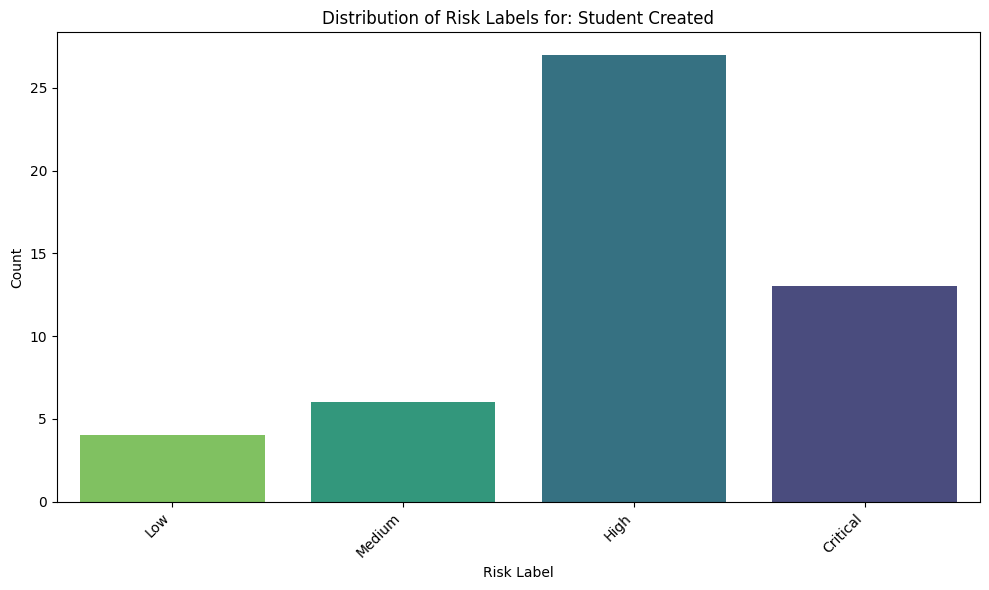

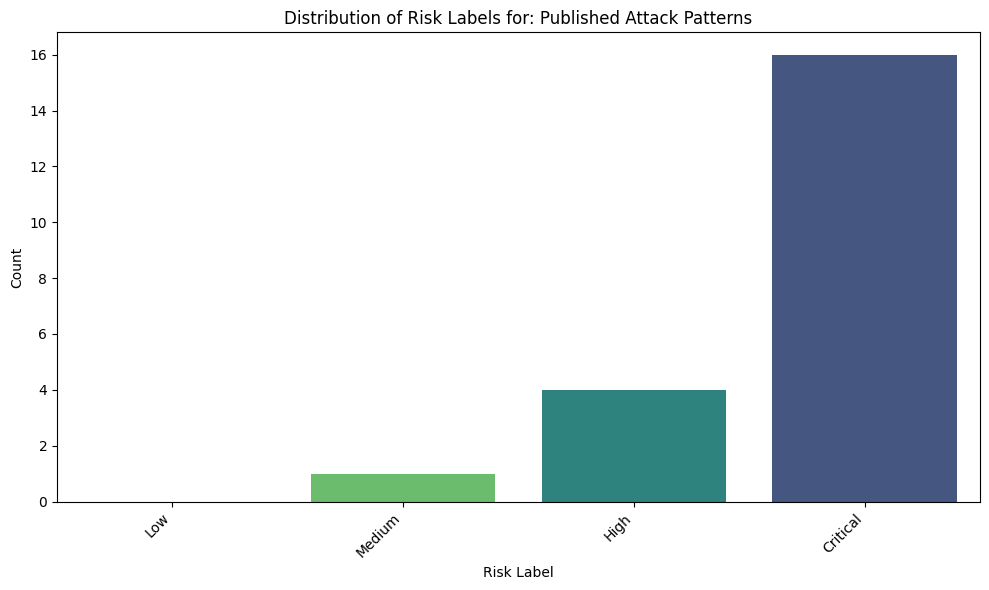

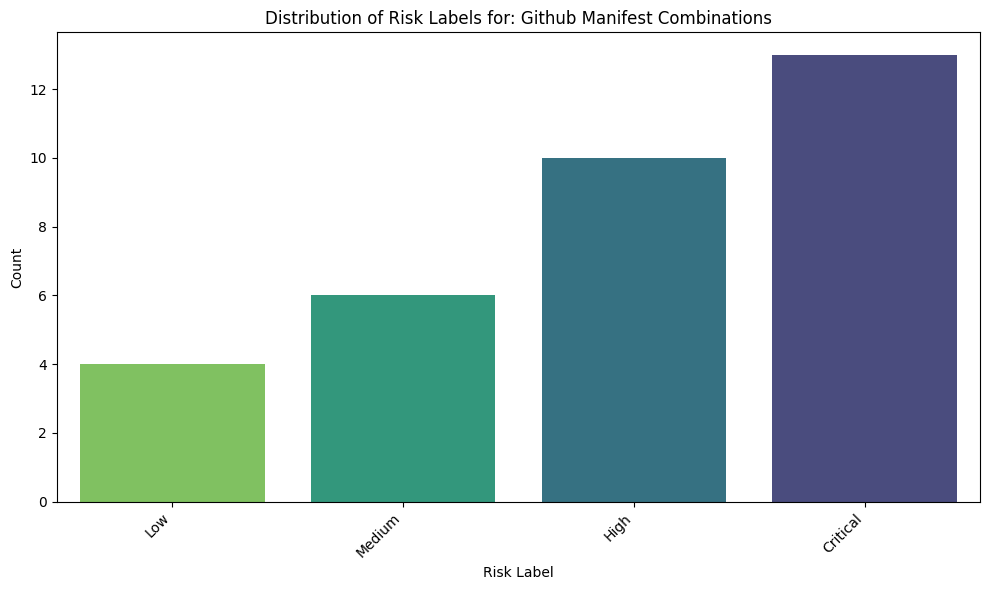

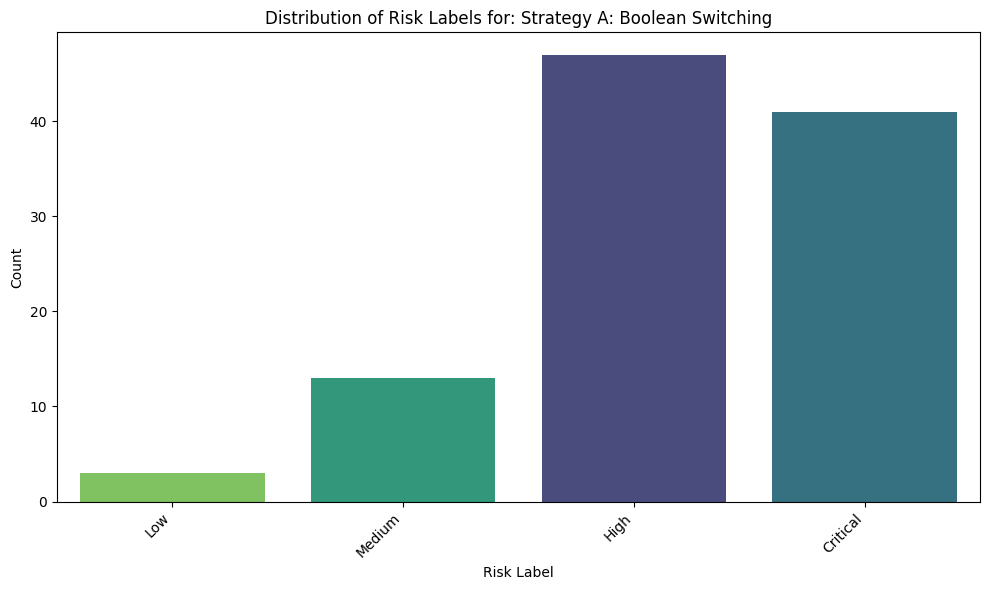

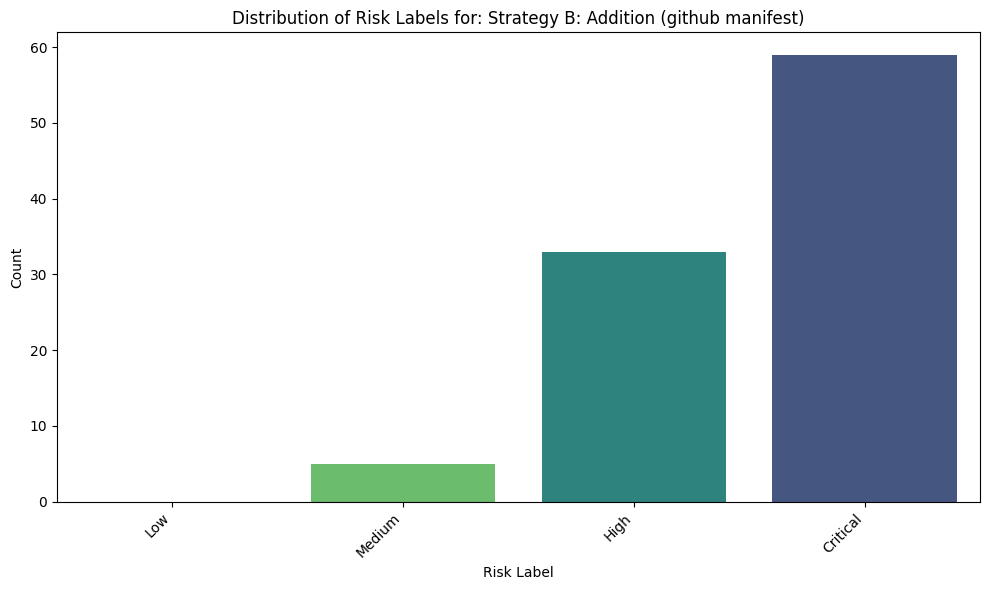

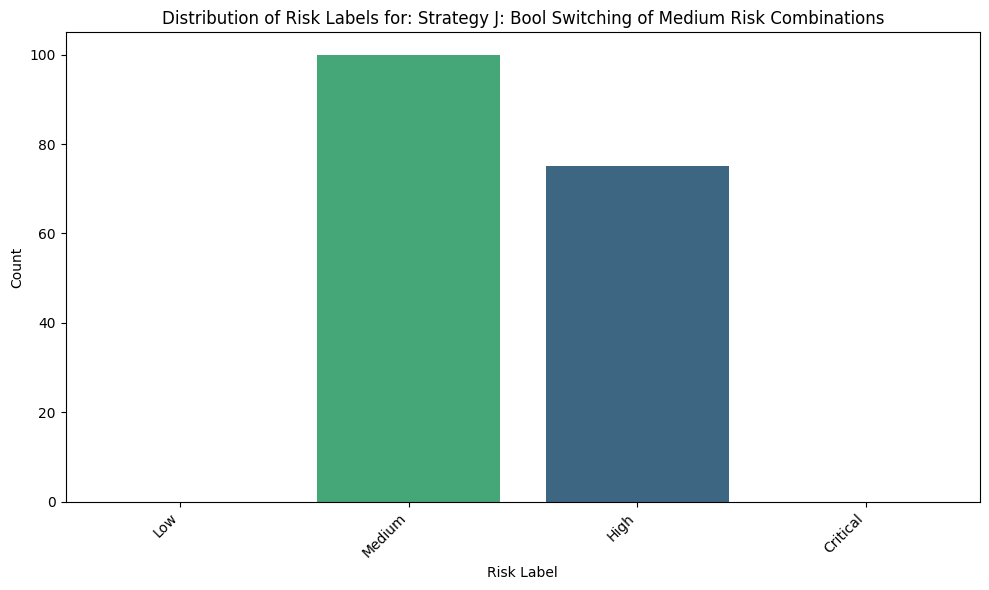

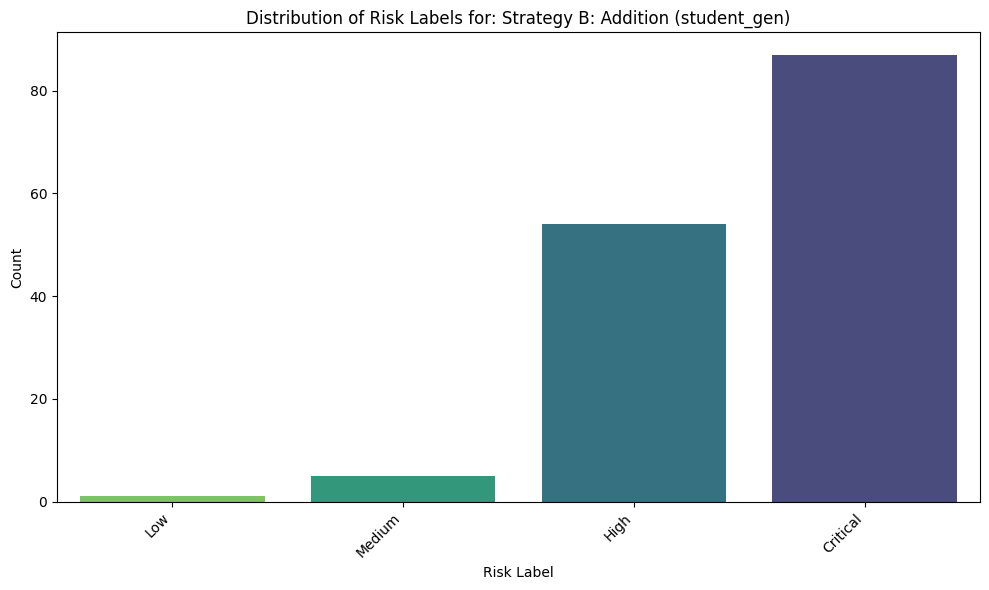

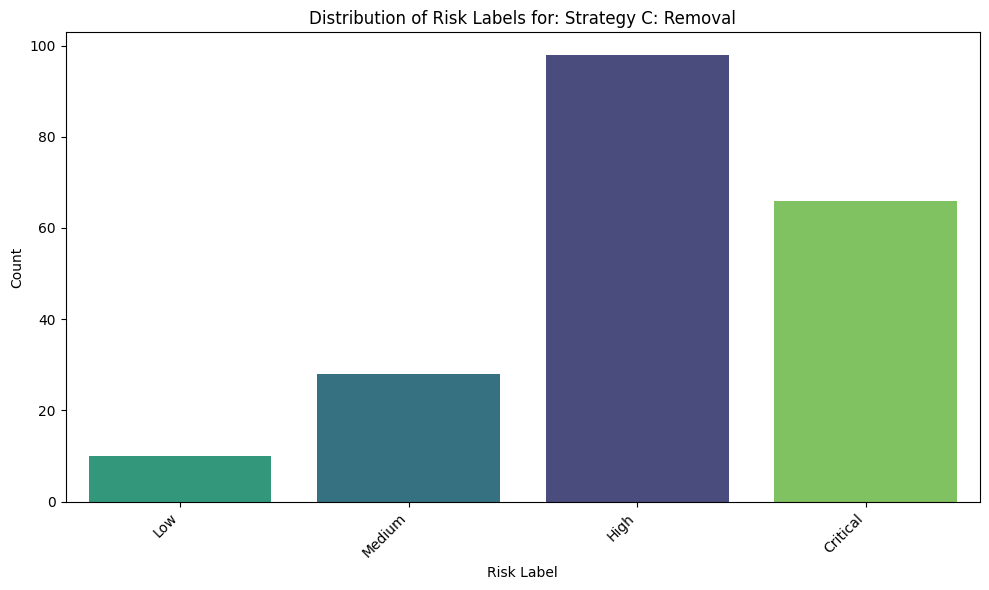

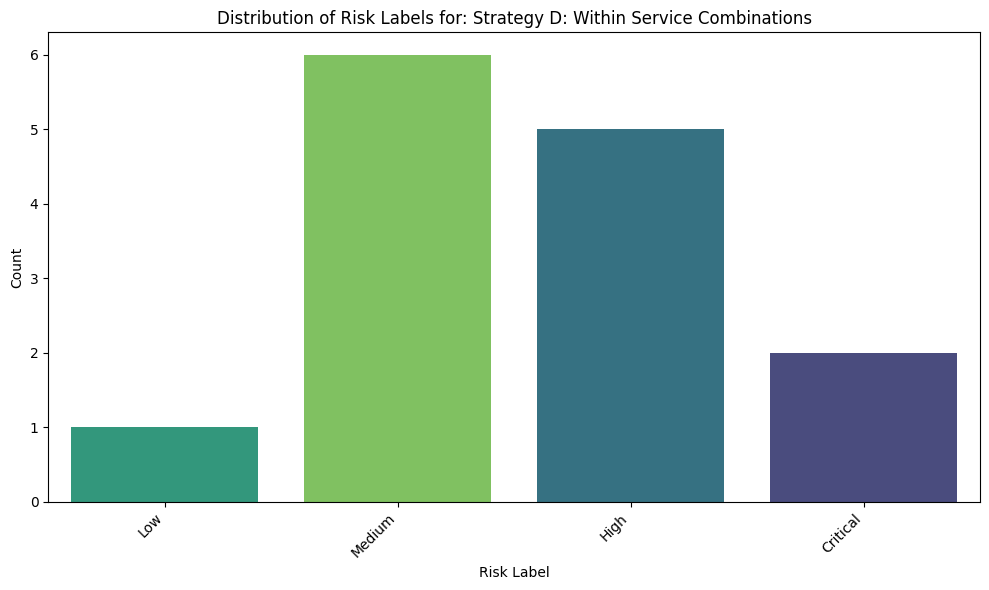

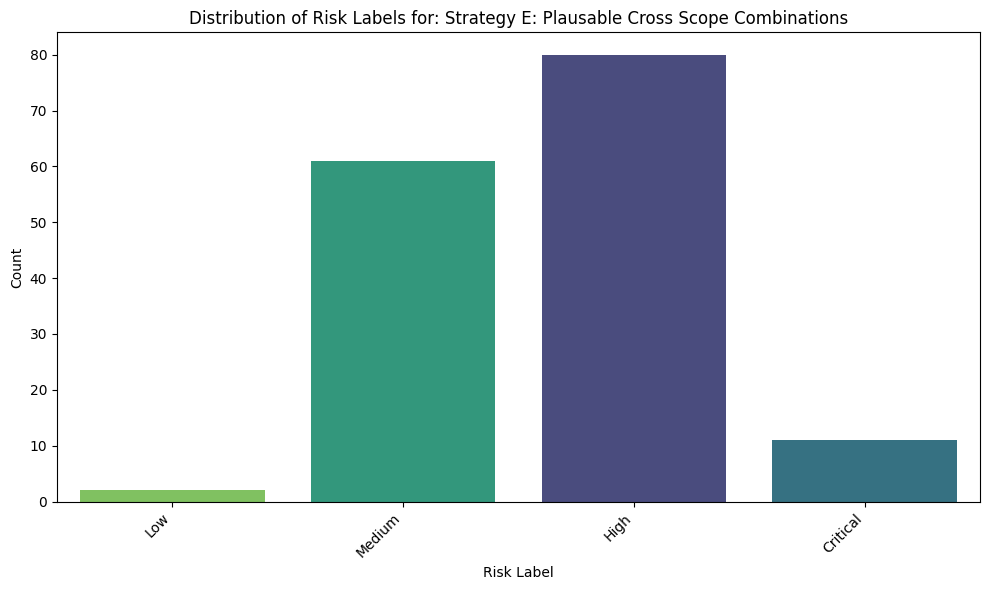

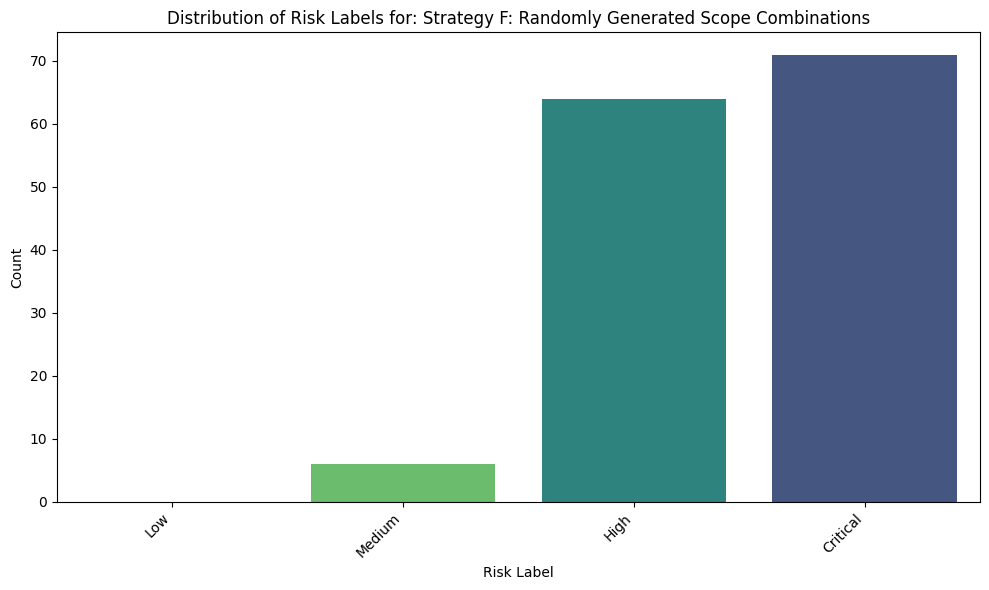

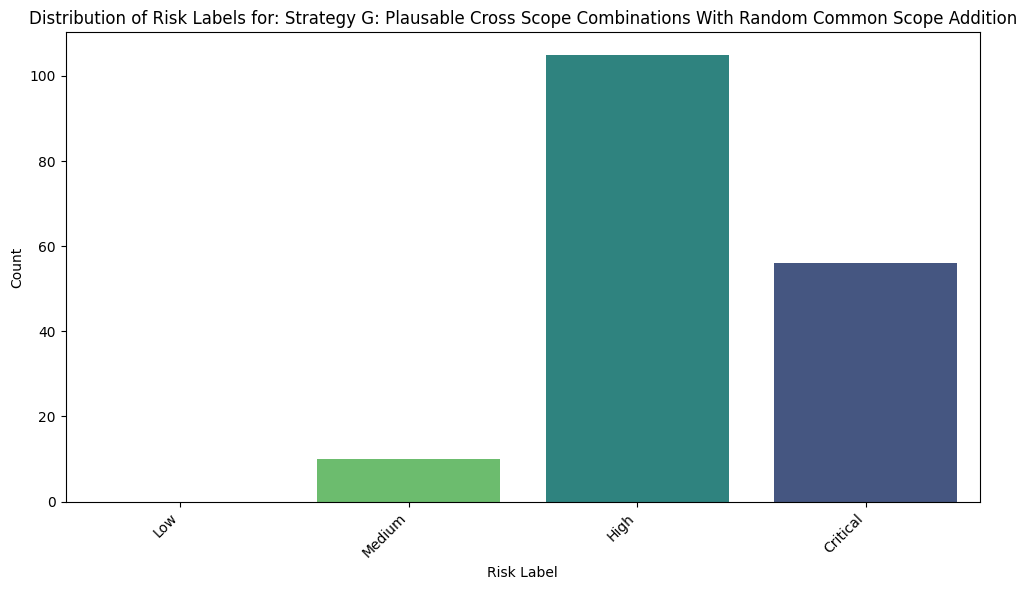

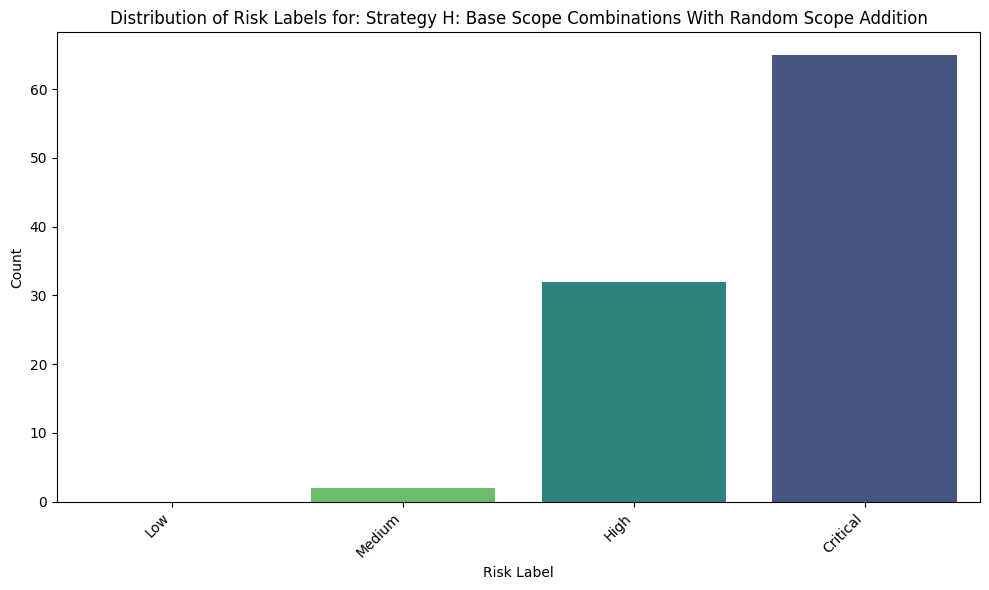

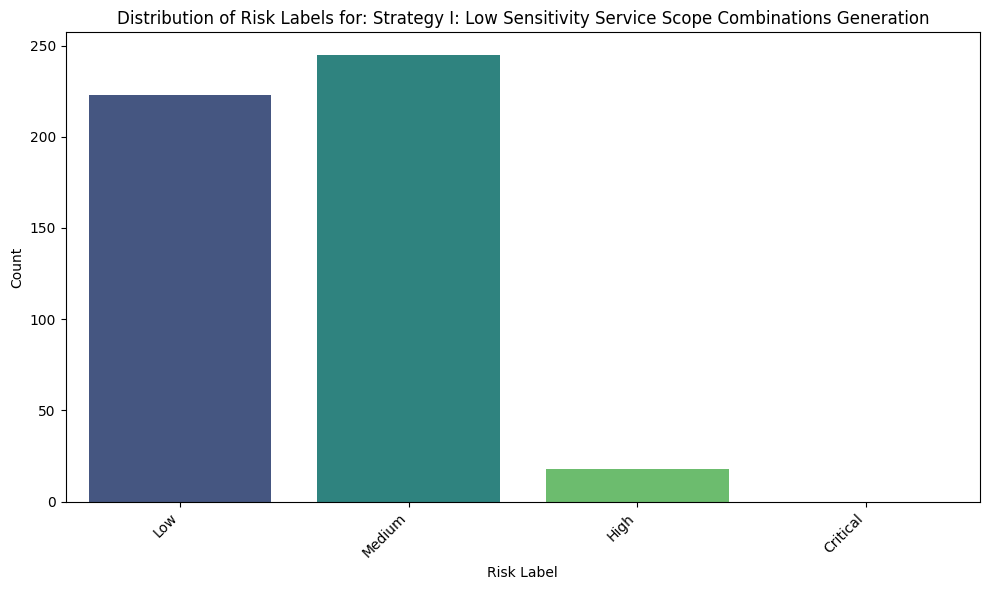

In [300]:
import matplotlib.pyplot as plt
import seaborn as sns

# Risk label distribution, one plot per source category.
source_categories = df_new['source_category'].unique()

for category in source_categories:
    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df_new[df_new['source_category'] == category],
        x='risk_label',
        order=['Low', 'Medium', 'High', 'Critical'],
        hue='risk_label',
        palette='viridis',
        legend=False,
    )
    plt.title(f'Distribution of Risk Labels for: {category}')
    plt.xlabel('Risk Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

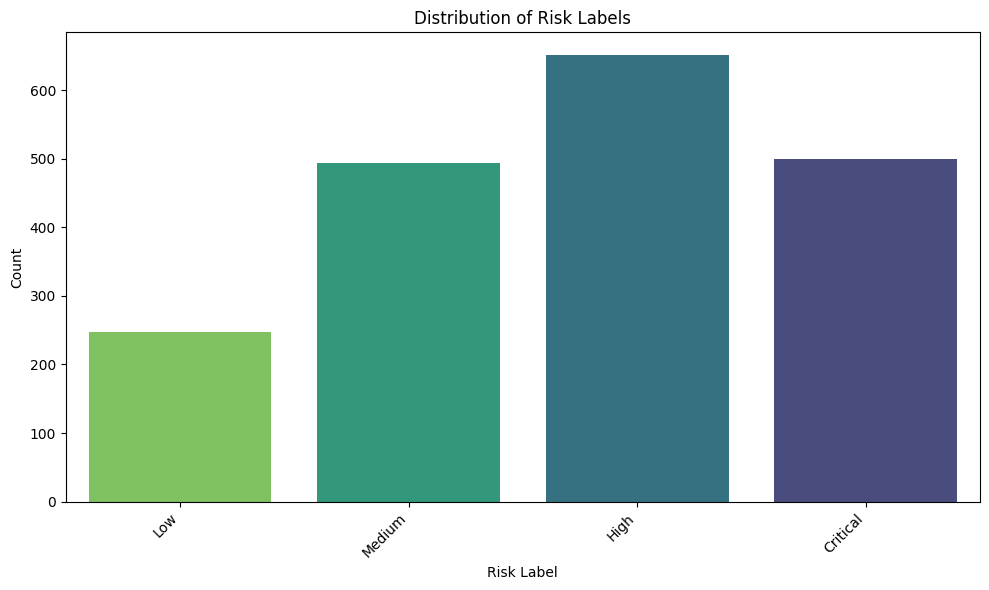

In [301]:
# Risk label distribution across the dataset as a whole.
source_categories = df_new['source_category'].unique()

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_new,
    x='risk_label',
    order=['Low', 'Medium', 'High', 'Critical'],
    hue='risk_label',
    palette='viridis',
    legend=False,
)
plt.title(f'Distribution of Risk Labels')
plt.xlabel('Risk Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()